# Bloomberg Take-home Challenge: Flight Analysis

## Executive Summary

This notebook analyzes 2024 U.S. flight operations from the BTS Reporting Carrier On-Time Performance dataset. The modeling target is whether a completed flight arrived 15 or more minutes late (`arr_delayed_15`). Cancelled and diverted flights are excluded from arrival-delay modeling because they do not have a standard arrival delay outcome.

Key EDA findings from the current analysis:
- The completed-flight dataset contains about 7.0 million records, with an overall 15+ minute arrival delay rate of about 20.8%.
- Arrival delay minutes are highly right-skewed: the median completed flight has 0 delay minutes, but the 95th percentile is about 83 minutes and extreme delays exceed 3,000 minutes.
- Delay risk is strongly time-dependent. It is lowest in the early morning and rises through the afternoon and evening, peaking around 19:00-20:00 scheduled departure time.
- Seasonality matters: July has the highest monthly delay rate, while October and November are among the lowest months.
- Delay rates vary by airline, airport, route, distance group, and holiday period, supporting the use of schedule, carrier, airport, route, distance, holiday, and airport-volume features in modeling.
- Actual departure delay is strongly related to arrival delay, but it should only be used in a post-departure model. The pre-flight model should exclude actual time, arrival outcome, and delay-cause fields to avoid leakage.


## 1. Data Loading

This section loads the 12 monthly BTS On-Time Performance CSV files for 2024, keeps the fields needed for exploratory analysis and modeling, combines them into a single flight-level dataset, and creates the primary modeling target: whether a flight arrived 15 or more minutes late.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install kaleido==0.2.1

import plotly.io as pio
pio.renderers.default = "png"

from IPython.display import Image, display
import os

os.makedirs("charts", exist_ok=True)

In [3]:
import pandas as pd
import numpy as np
import glob
import os
import gc
import plotly.express as px
import holidays

DATA_DIR = "/content/drive/MyDrive/flight"

csv_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.csv")))

use_cols = [
    "Year", "Quarter", "Month", "DayofMonth", "DayOfWeek", "FlightDate",
    "Reporting_Airline", "IATA_CODE_Reporting_Airline",
    "Origin", "OriginCityName", "OriginStateName",
    "Dest", "DestCityName", "DestStateName",
    "CRSDepTime", "DepTime", "DepDelayMinutes", "DepDel15", "DepTimeBlk",
    "CRSArrTime", "ArrTime", "ArrDelayMinutes", "ArrDel15", "ArrTimeBlk",
    "Cancelled", "Diverted",
    "CRSElapsedTime", "ActualElapsedTime", "AirTime",
    "Distance", "DistanceGroup",
    "CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay", "LateAircraftDelay"
]

df_list = []

for file in csv_files:
    print("Reading:", os.path.basename(file))

    temp = pd.read_csv(
        file,
        usecols=lambda col: col in use_cols,
        low_memory=False
    )

    # Keep only completed flights immediately
    temp = temp[
        (temp["Cancelled"] == 0) &
        (temp["Diverted"] == 0)
    ]

    df_list.append(temp)

    del temp
    gc.collect()

completed_flights = pd.concat(df_list, ignore_index=True)

del df_list
gc.collect()

print("Completed flights shape:", completed_flights.shape)
completed_flights.head()

Reading: On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2024_1.csv
Reading: On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2024_10.csv
Reading: On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2024_11.csv
Reading: On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2024_12.csv
Reading: On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2024_2.csv
Reading: On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2024_3.csv
Reading: On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2024_4.csv
Reading: On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2024_5.csv
Reading: On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2024_6.csv
Reading: On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2024_7.csv
Reading: On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2024_8.csv
Reading: On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2024_9.csv
Completed flights shape: 

,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,IATA_CODE_Reporting_Airline,Origin,OriginCityName,...,CRSElapsedTime,ActualElapsedTime,AirTime,Distance,DistanceGroup,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,2024,1,1,8,1,2024-01-08,9E,9E,LGA,"New York, NY",...,219.0,213.0,184.0,1148.0,5,NaN,NaN,NaN,NaN,NaN
1,2024,1,1,9,2,2024-01-09,9E,9E,LGA,"New York, NY",...,219.0,196.0,168.0,1148.0,5,NaN,NaN,NaN,NaN,NaN
2,2024,1,1,10,3,2024-01-10,9E,9E,LGA,"New York, NY",...,219.0,200.0,177.0,1148.0,5,NaN,NaN,NaN,NaN,NaN
3,2024,1,1,11,4,2024-01-11,9E,9E,LGA,"New York, NY",...,219.0,223.0,188.0,1148.0,5,0.0,0.0,4.0,0.0,23.0
4,2024,1,1,12,5,2024-01-12,9E,9E,LGA,"New York, NY",...,219.0,226.0,185.0,1148.0,5,NaN,NaN,NaN,NaN,NaN


### Data Loading Notes

The raw monthly CSV files are loaded one month at a time, filtered to completed flights, and concatenated into a single analysis dataset. This avoids the memory issue caused by loading the full 7.1 million-row dataset and then making another copy for filtering.


The dataset contains 7.1 million flight records from January 1, 2024 through December 31, 2024.

Some missing values are expected:
- `CancellationCode` is missing for most records because it is only populated when a flight is cancelled.
- Delay cause columns such as `CarrierDelay`, `WeatherDelay`, `NASDelay`, `SecurityDelay`, and `LateAircraftDelay` are mostly missing because BTS only reports detailed delay causes for delayed flights.
- Arrival-related fields such as `ArrDelay`, `ArrDelayMinutes`, and `ArrDel15` are missing mostly for cancelled or diverted flights, where an actual arrival outcome does not exist.

Because the full 2024 BTS dataset contains over 7 million rows, I filtered out cancelled and diverted flights during the loading step to reduce memory usage. These records are excluded from arrival delay modeling because they do not have a standard arrival delay outcome.

In [4]:
completed_flights["FlightDate"] = pd.to_datetime(completed_flights["FlightDate"])

completed_flights["arr_delayed_15"] = completed_flights["ArrDel15"].astype("int8")

completed_flights["arr_delayed_15"].value_counts(normalize=True)

,proportion
arr_delayed_15,
0,0.791828
1,0.208172


In [5]:
for col in ["Year", "Quarter", "Month", "DayofMonth", "DayOfWeek",
            "Cancelled", "Diverted", "DistanceGroup", "arr_delayed_15"]:
    if col in completed_flights.columns:
        completed_flights[col] = pd.to_numeric(completed_flights[col], downcast="integer")

for col in ["DepDelayMinutes", "ArrDelayMinutes", "CRSElapsedTime",
            "ActualElapsedTime", "AirTime", "Distance",
            "CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay", "LateAircraftDelay"]:
    if col in completed_flights.columns:
        completed_flights[col] = pd.to_numeric(completed_flights[col], downcast="float")

for col in ["Reporting_Airline", "IATA_CODE_Reporting_Airline",
            "Origin", "OriginCityName", "OriginStateName",
            "Dest", "DestCityName", "DestStateName",
            "DepTimeBlk", "ArrTimeBlk"]:
    if col in completed_flights.columns:
        completed_flights[col] = completed_flights[col].astype("category")

completed_flights.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6965247 entries, 0 to 6965246
Data columns (total 37 columns):
 #   Column                       Dtype         
---  ------                       -----         
 0   Year                         int16         
 1   Quarter                      int8          
 2   Month                        int8          
 3   DayofMonth                   int8          
 4   DayOfWeek                    int8          
 5   FlightDate                   datetime64[ns]
 6   Reporting_Airline            category      
 7   IATA_CODE_Reporting_Airline  category      
 8   Origin                       category      
 9   OriginCityName               category      
 10  OriginStateName              category      
 11  Dest                         category      
 12  DestCityName                 category      
 13  DestStateName                category      
 14  CRSDepTime                   int64         
 15  DepTime                      float64       
 16  

In [6]:
completed_flights.to_parquet(
    "/content/drive/MyDrive/flight/completed_flights_2024.parquet",
    index=False
)

## 2. Data Cleaning

This section checks duplicate records, validates missingness in core analysis fields, and confirms that the target variable is available for completed flights.


In [7]:
pd.options.display.float_format = "{:,.2f}".format

duplicate_count = completed_flights.duplicated().sum()
duplicate_share = duplicate_count / len(completed_flights)

print(f"Duplicate rows: {duplicate_count:,}")
print(f"Duplicate share: {duplicate_share:.4%}")

Duplicate rows: 0
Duplicate share: 0.0000%


In [8]:
key_cols = [
    "FlightDate", "Reporting_Airline", "Origin", "Dest",
    "CRSDepTime", "CRSArrTime",
    "DepDelayMinutes", "ArrDelayMinutes", "ArrDel15",
    "Distance"
]

missing_key = (
    completed_flights[key_cols]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .to_frame("missing_share")
)

missing_key

,missing_share
FlightDate,0.00
Reporting_Airline,0.00
Origin,0.00
Dest,0.00
CRSDepTime,0.00
CRSArrTime,0.00
DepDelayMinutes,0.00
ArrDelayMinutes,0.00
ArrDel15,0.00
Distance,0.00


### Data Cleaning Summary

There are no duplicate rows in the completed-flight dataset, and the key fields used for EDA and modeling have no missing values after excluding cancelled and diverted flights. This means the core delay analysis can proceed without imputation for flight date, carrier, origin, destination, schedule time, distance, or arrival-delay outcome.


## 3. Feature Engineering

The features below are designed to be available before or near scheduled departure. They include calendar features, scheduled time features, route identifiers, holiday flags, and airport-size proxies. Post-outcome fields such as actual arrival time, arrival delay minutes, and delay-cause fields are kept for EDA only and excluded from pre-flight modeling.


In [9]:
# Date-based features

completed_flights["day_name"] = completed_flights["FlightDate"].dt.day_name()
completed_flights["week"] = completed_flights["FlightDate"].dt.isocalendar().week.astype("int16")
completed_flights["is_weekend"] = completed_flights["DayOfWeek"].isin([6, 7]).astype("int8")

In [10]:
# Convert CRSDepTime into scheduled departure hour
# BTS time format is HHMM, e.g. 5 -> 00:05, 1330 -> 13:30

completed_flights["sched_dep_hour"] = (completed_flights["CRSDepTime"] // 100).astype("int8")
completed_flights["sched_arr_hour"] = (completed_flights["CRSArrTime"] // 100).astype("int8")

completed_flights[["CRSDepTime", "sched_dep_hour", "CRSArrTime", "sched_arr_hour"]].head()

,CRSDepTime,sched_dep_hour,CRSArrTime,sched_arr_hour
0,856,8,1135,11
1,856,8,1135,11
2,856,8,1135,11
3,856,8,1135,11
4,856,8,1135,11


In [11]:
completed_flights["route"] = completed_flights["Origin"].astype(str) + "-" + completed_flights["Dest"].astype(str)

completed_flights[["Origin", "Dest", "route"]].head()

,Origin,Dest,route
0,LGA,OMA,LGA-OMA
1,LGA,OMA,LGA-OMA
2,LGA,OMA,LGA-OMA
3,LGA,OMA,LGA-OMA
4,LGA,OMA,LGA-OMA


In [12]:
# Holiday features: exact federal holiday and +/- 2 day holiday travel window
completed_flights["FlightDate"] = pd.to_datetime(completed_flights["FlightDate"])

us_holidays = holidays.US(years=[2024])
holiday_dates = pd.to_datetime(list(us_holidays.keys()))

completed_flights["is_holiday"] = (
    completed_flights["FlightDate"].dt.normalize().isin(holiday_dates)
).astype("int8")

holiday_window = set()
for h in holiday_dates:
    for offset in range(-2, 3):
        holiday_window.add(h + pd.Timedelta(days=offset))

completed_flights["is_holiday_week"] = (
    completed_flights["FlightDate"].dt.normalize().isin(holiday_window)
).astype("int8")

completed_flights[["is_holiday", "is_holiday_week"]].mean()


,0
is_holiday,0.03
is_holiday_week,0.14


In [13]:
# Airport size features based on annual completed-flight volume
origin_size = (
    completed_flights.groupby("Origin", observed=True)
    .size()
    .reset_index(name="origin_annual_volume")
)

dest_size = (
    completed_flights.groupby("Dest", observed=True)
    .size()
    .reset_index(name="dest_annual_volume")
)

# Avoid duplicating columns if this cell is re-run
completed_flights = completed_flights.drop(
    columns=["origin_annual_volume", "dest_annual_volume"],
    errors="ignore"
)

completed_flights = completed_flights.merge(origin_size, on="Origin", how="left")
completed_flights = completed_flights.merge(dest_size, on="Dest", how="left")

completed_flights[["Origin", "Dest", "origin_annual_volume", "dest_annual_volume"]].head()


,Origin,Dest,origin_annual_volume,dest_annual_volume
0,LGA,OMA,158152,23438
1,LGA,OMA,158152,23438
2,LGA,OMA,158152,23438
3,LGA,OMA,158152,23438
4,LGA,OMA,158152,23438


In [14]:
# Optional pre-flight congestion proxy: same-origin departure volume by date and scheduled hour.
# This is useful for modeling, but the merge can be memory-heavy in Colab, so it is off by default.
RUN_OPTIONAL_CONGESTION_FEATURE = False

if RUN_OPTIONAL_CONGESTION_FEATURE:
    origin_hour_volume = (
        completed_flights.groupby(["Origin", "FlightDate", "sched_dep_hour"], observed=True)
        .size()
        .reset_index(name="origin_hourly_departure_volume")
    )

    completed_flights = completed_flights.drop(
        columns=["origin_hourly_departure_volume"],
        errors="ignore"
    )

    completed_flights = completed_flights.merge(
        origin_hour_volume,
        on=["Origin", "FlightDate", "sched_dep_hour"],
        how="left"
    )

    display(completed_flights[["Origin", "FlightDate", "sched_dep_hour", "origin_hourly_departure_volume"]].head())
else:
    print("Skipped optional congestion feature. Set RUN_OPTIONAL_CONGESTION_FEATURE = True to create it.")


Skipped optional congestion feature. Set RUN_OPTIONAL_CONGESTION_FEATURE = True to create it.


### Feature Engineering Summary

Created modeling candidates:
- Calendar: `Month`, `DayOfWeek`, `day_name`, `week`, `is_weekend`, `is_holiday`, `is_holiday_week`
- Schedule timing: `sched_dep_hour`, `sched_arr_hour`, `CRSDepTime`, `CRSArrTime`, `CRSElapsedTime`
- Geography and network: `Reporting_Airline`, `Origin`, `Dest`, `route`, `Distance`, `DistanceGroup`
- Operational scale: `origin_annual_volume`, `dest_annual_volume`, and optional `origin_hourly_departure_volume`

Historical delay-rate features by carrier, airport, or route were not added here because they require careful time-based construction to avoid leakage. They are good candidates for a later modeling iteration if computed using only prior dates.


## 4. Exploratory Data Analysis

The EDA is organized around the modeling question: which pre-flight factors are associated with a higher probability of arriving 15 or more minutes late?


### 4.1 Overall Delay Rate and Delay Distribution


In [15]:
delay_summary = (
    completed_flights["arr_delayed_15"]
    .value_counts()
    .rename(index={0: "Not delayed 15+ min", 1: "Delayed 15+ min"})
    .to_frame("flight_count")
)

delay_summary["share"] = delay_summary["flight_count"] / delay_summary["flight_count"].sum()

delay_summary

,flight_count,share
arr_delayed_15,,
Not delayed 15+ min,5515281,0.79
Delayed 15+ min,1449966,0.21


In [16]:
overall_delay_rate = completed_flights["arr_delayed_15"].mean()

print(f"Overall arrival delay rate, 15+ minutes: {overall_delay_rate:.2%}")

Overall arrival delay rate, 15+ minutes: 20.82%


In [17]:
delay_stats = completed_flights["ArrDelayMinutes"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

delay_stats

,ArrDelayMinutes
count,"6,965,247.00"
mean,15.90
std,53.41
min,0.00
50%,0.00
75%,9.00
90%,43.00
95%,83.00
99%,215.00
max,"3,803.00"


/tmp/ipykernel_87081/3933790989.py:71: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image("charts/delay_distribution.png", width=900, height=500, scale=2)


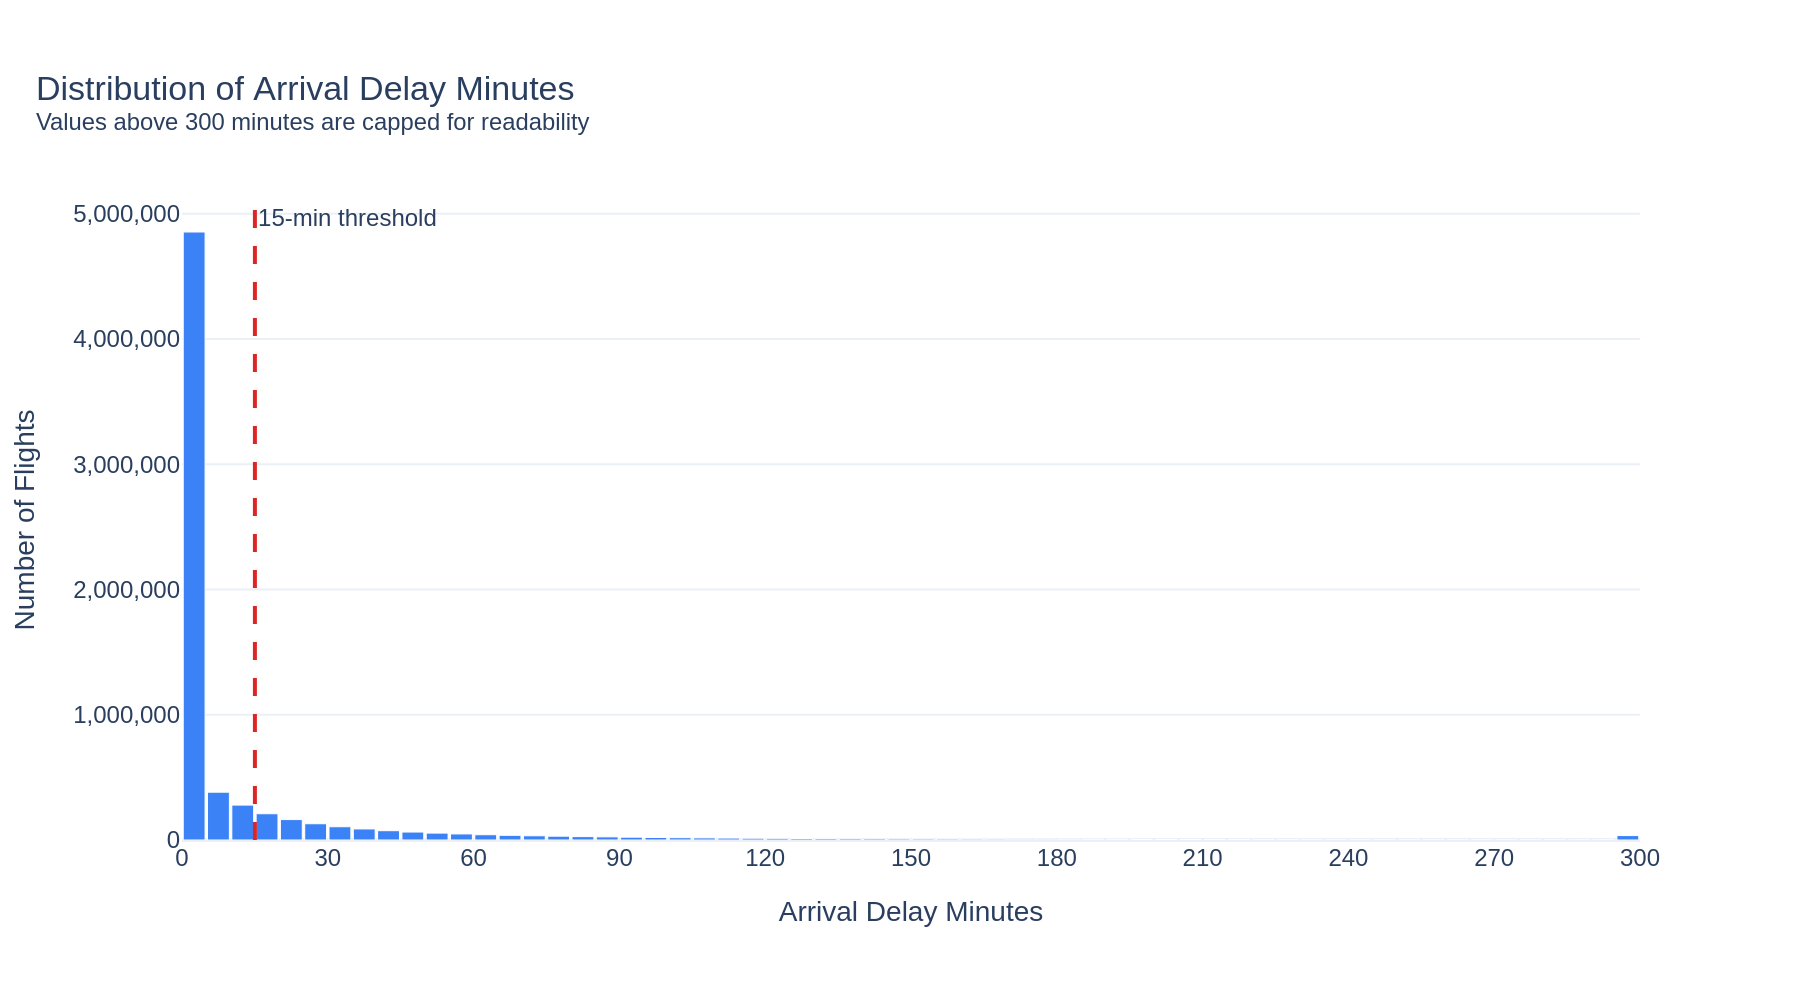

In [18]:
# Cap extreme delays for readability without copying the full dataframe
arr_delay_capped = completed_flights["ArrDelayMinutes"].clip(upper=300)

hist_counts, hist_edges = np.histogram(
    arr_delay_capped,
    bins=60,
    range=(0, 300)
)

hist_df = pd.DataFrame({
    "delay_bin_start": hist_edges[:-1],
    "delay_bin_end": hist_edges[1:],
    "delay_bin_midpoint": (hist_edges[:-1] + hist_edges[1:]) / 2,
    "flight_count": hist_counts
})

fig = px.bar(
    hist_df,
    x="delay_bin_midpoint",
    y="flight_count",
    title="Distribution of Arrival Delay Minutes",
    labels={
        "delay_bin_midpoint": "Arrival Delay Minutes",
        "flight_count": "Number of Flights"
    },
    color_discrete_sequence=["#3B82F6"],
    hover_data={
        "delay_bin_start": ":.0f",
        "delay_bin_end": ":.0f",
        "delay_bin_midpoint": False,
        "flight_count": ":,"
    }
)

fig.add_vline(
    x=15,
    line_width=2,
    line_dash="dash",
    line_color="#DC2626",
    annotation_text="15-min threshold",
    annotation_position="top right"
)

fig.update_traces(width=4.5)

fig.update_layout(
    height=500,
    width=900,
    template="plotly_white",
    title=dict(
        text="Distribution of Arrival Delay Minutes<br><sup>Values above 300 minutes are capped for readability</sup>",
        x=0.02,
        xanchor="left"
    ),
    bargap=0.03,
    xaxis=dict(
        title="Arrival Delay Minutes",
        tickmode="linear",
        dtick=30,
        range=[0, 300]
    ),
    yaxis=dict(
        title="Number of Flights",
        tickformat=","
    ),
    showlegend=False
)

fig.show()

# fig.write_image("charts/delay_distribution.png", width=900, height=500, scale=2)
# display(Image("charts/delay_distribution.png"))

In [19]:
# Look at extreme arrival delays

completed_flights.nlargest(10, "ArrDelayMinutes")[
    ["FlightDate", "Reporting_Airline", "Origin", "Dest", "ArrDelayMinutes", "DepDelayMinutes"]
]

,FlightDate,Reporting_Airline,Origin,Dest,ArrDelayMinutes,DepDelayMinutes
5235060,2024-07-05,AA,AUS,MIA,"3,803.00","3,777.00"
2827508,2024-03-18,AA,SEA,CLT,"3,359.00","3,360.00"
3431124,2024-04-08,AA,SAN,PHX,"3,354.00","3,348.00"
1777743,2024-12-27,AA,SMF,ORD,"3,241.00","3,274.00"
1791770,2024-12-19,AA,GRR,DFW,"3,208.00","3,250.00"
6748960,2024-09-07,AA,CMH,CLT,"3,143.00","3,130.00"
73440,2024-01-08,AA,IAH,DFW,"3,136.00","3,125.00"
3469026,2024-04-25,AA,LAS,DFW,"3,023.00","3,006.00"
3419395,2024-04-07,AA,SJU,DFW,"3,020.00","2,963.00"
3427768,2024-04-21,AA,PDX,DFW,"3,007.00","3,024.00"


**Insight.** About 20.8% of completed flights arrived 15+ minutes late in 2024. The delay distribution is very right-skewed: most flights arrive on time or with small delays, but a small number of flights experience very large delays. For visualization, delay minutes are capped at 300 minutes; the underlying records are not removed.


### 4.2 Temporal Patterns


In [20]:
monthly_delay = (
    completed_flights.groupby("Month", observed=True)
    .agg(
        flight_count=("arr_delayed_15", "size"),
        delay_rate=("arr_delayed_15", "mean"),
        avg_arr_delay=("ArrDelayMinutes", "mean")
    )
    .reset_index()
)

monthly_delay

,Month,flight_count,delay_rate,avg_arr_delay
0,1,525370,0.24,19.20
1,2,515269,0.16,11.17
2,3,585413,0.21,15.56
3,4,576915,0.19,14.11
4,5,599226,0.26,21.30
5,6,601272,0.25,19.39
6,7,613938,0.30,24.93
7,8,604303,0.23,18.54
8,9,578262,0.16,10.49
9,10,608514,0.13,8.92


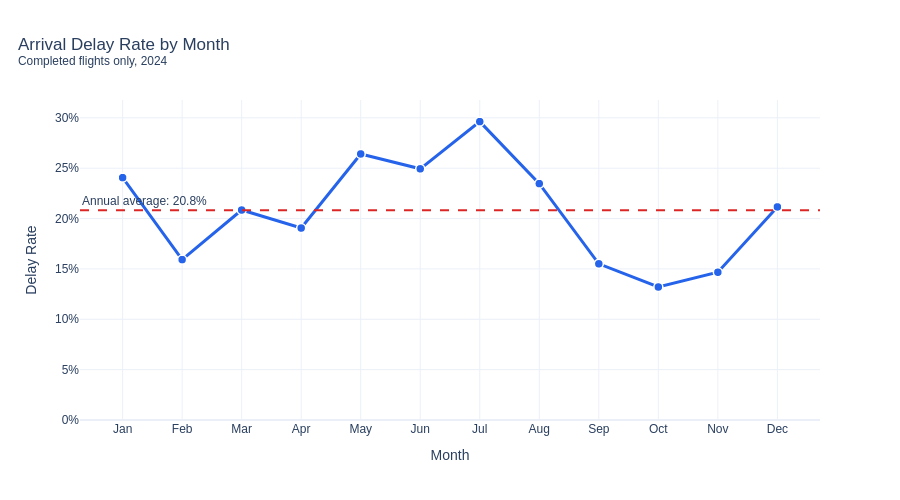

In [21]:
monthly_plot = monthly_delay.copy()
monthly_plot["Month_Name"] = pd.to_datetime(
    monthly_plot["Month"], format="%m"
).dt.strftime("%b")

fig = px.line(
    monthly_plot,
    x="Month_Name",
    y="delay_rate",
    markers=True,
    title="Arrival Delay Rate by Month",
    labels={
        "Month_Name": "Month",
        "delay_rate": "Delay Rate"
    },
    hover_data={
        "Month_Name": False,
        "delay_rate": ":.1%",
        "flight_count": ":,",
        "avg_arr_delay": ":.2f"
    }
)

fig.update_traces(
    line=dict(color="#2563EB", width=3),
    marker=dict(size=9, color="#2563EB", line=dict(width=1.5, color="white"))
)

fig.update_layout(
    template="plotly_white",
    height=500,
    width=900,
    title=dict(
        text="Arrival Delay Rate by Month<br><sup>Completed flights only, 2024</sup>",
        x=0.02,
        xanchor="left"
    ),
    xaxis=dict(
        title="Month",
        categoryorder="array",
        categoryarray=["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                       "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
    ),
    yaxis=dict(
        title="Delay Rate",
        tickformat=".0%",
        rangemode="tozero"
    ),
    hovermode="x unified"
)

annual_delay_rate = completed_flights["arr_delayed_15"].mean()

fig.add_hline(
    y=annual_delay_rate,
    line_dash="dash",
    line_color="#DC2626",
    annotation_text=f"Annual average: {annual_delay_rate:.1%}",
    annotation_position="top left"
)

fig.show()

In [22]:
dow_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

dow_delay = (
    completed_flights.groupby("day_name", observed=True)
    .agg(
        flight_count=("arr_delayed_15", "size"),
        delay_rate=("arr_delayed_15", "mean"),
        avg_arr_delay=("ArrDelayMinutes", "mean")
    )
    .reindex(dow_order)
    .reset_index()
)

dow_delay

,day_name,flight_count,delay_rate,avg_arr_delay
0,Monday,1056394,0.21,15.82
1,Tuesday,961060,0.18,14.13
2,Wednesday,958696,0.19,14.11
3,Thursday,1024391,0.22,16.50
4,Friday,1037084,0.23,17.69
5,Saturday,898255,0.20,15.62
6,Sunday,1029367,0.23,17.12


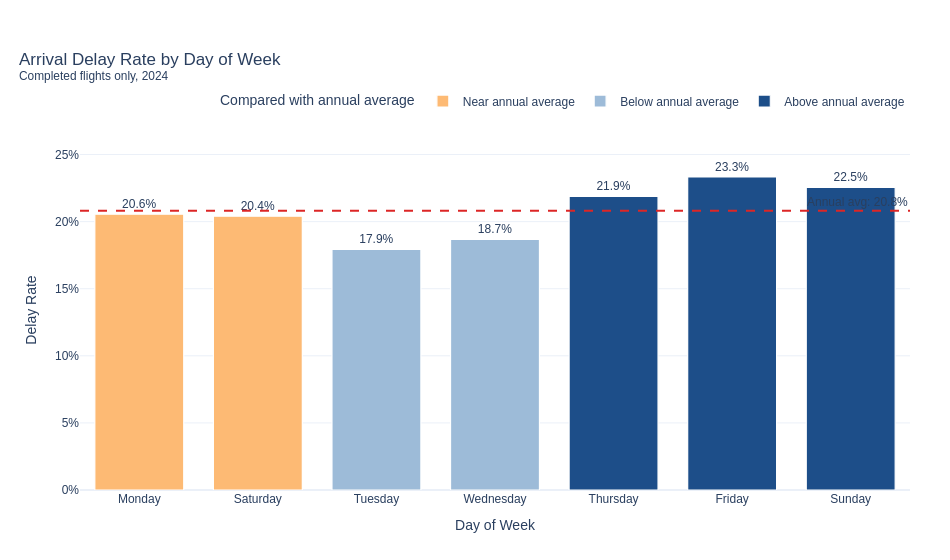

In [23]:
annual_delay_rate = completed_flights["arr_delayed_15"].mean()

dow_plot = dow_delay.copy()

dow_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

dow_plot["day_name"] = pd.Categorical(
    dow_plot["day_name"],
    categories=dow_order,
    ordered=True
)

dow_plot = dow_plot.sort_values("day_name")

# Create interpretable color categories
dow_plot["vs_annual_avg"] = np.where(
    dow_plot["delay_rate"] > annual_delay_rate + 0.005,
    "Above annual average",
    np.where(
        dow_plot["delay_rate"] < annual_delay_rate - 0.005,
        "Below annual average",
        "Near annual average"
    )
)

fig = px.bar(
    dow_plot,
    x="day_name",
    y="delay_rate",
    color="vs_annual_avg",
    text="delay_rate",
    title="Arrival Delay Rate by Day of Week",
    labels={
        "day_name": "Day of Week",
        "delay_rate": "Delay Rate",
        "vs_annual_avg": "Compared with annual average"
    },
    hover_data={
        "day_name": False,
        "delay_rate": ":.1%",
        "flight_count": ":,",
        "avg_arr_delay": ":.2f",
        "vs_annual_avg": True
    },
    color_discrete_map={
        "Below annual average": "#9DBBD8",
        "Near annual average": "#FDBA74",
        "Above annual average": "#1D4E89"
    }
)

fig.update_traces(
    texttemplate="%{text:.1%}",
    textposition="outside",
    cliponaxis=False,
    marker_line_color="white",
    marker_line_width=1.2
)

fig.add_hline(
    y=annual_delay_rate,
    line_dash="dash",
    line_color="#DC2626",
    annotation_text=f"Annual avg: {annual_delay_rate:.1%}",
    annotation_position="top right"
)

fig.update_layout(
    template="plotly_white",
    height=560,
    width=950,
    title=dict(
        text="Arrival Delay Rate by Day of Week<br><sup>Completed flights only, 2024</sup>",
        x=0.02,
        xanchor="left"
    ),
    xaxis=dict(
        title="Day of Week",
        tickangle=0
    ),
    yaxis=dict(
        title="Delay Rate",
        tickformat=".0%",
        range=[0, dow_plot["delay_rate"].max() + 0.035]
    ),
    legend=dict(
        title="Compared with annual average",
        orientation="h",
        yanchor="bottom",
        y=1.04,
        xanchor="right",
        x=1
    ),
    margin=dict(t=130, r=40, b=70, l=80),
    bargap=0.25
)

fig.show()

In [24]:
completed_flights["sched_dep_hour"] = (completed_flights["CRSDepTime"] // 100).astype("int8")
completed_flights["sched_arr_hour"] = (completed_flights["CRSArrTime"] // 100).astype("int8")

# BTS sometimes uses 2400 for midnight; convert it to 0
completed_flights["sched_dep_hour"] = completed_flights["sched_dep_hour"].replace(24, 0)
completed_flights["sched_arr_hour"] = completed_flights["sched_arr_hour"].replace(24, 0)

hourly_delay = (
    completed_flights.groupby("sched_dep_hour", observed=True)
    .agg(
        flight_count=("arr_delayed_15", "size"),
        delay_rate=("arr_delayed_15", "mean"),
        avg_arr_delay=("ArrDelayMinutes", "mean")
    )
    .reset_index()
)

hourly_delay

,sched_dep_hour,flight_count,delay_rate,avg_arr_delay
0,0,12103,0.20,16.61
1,1,4001,0.21,17.63
2,2,1511,0.21,14.59
3,3,1069,0.19,14.69
4,4,526,0.20,21.22
5,5,197159,0.09,9.74
6,6,487660,0.10,9.03
7,7,486842,0.12,9.90
8,8,476025,0.14,10.19
9,9,390538,0.15,11.06


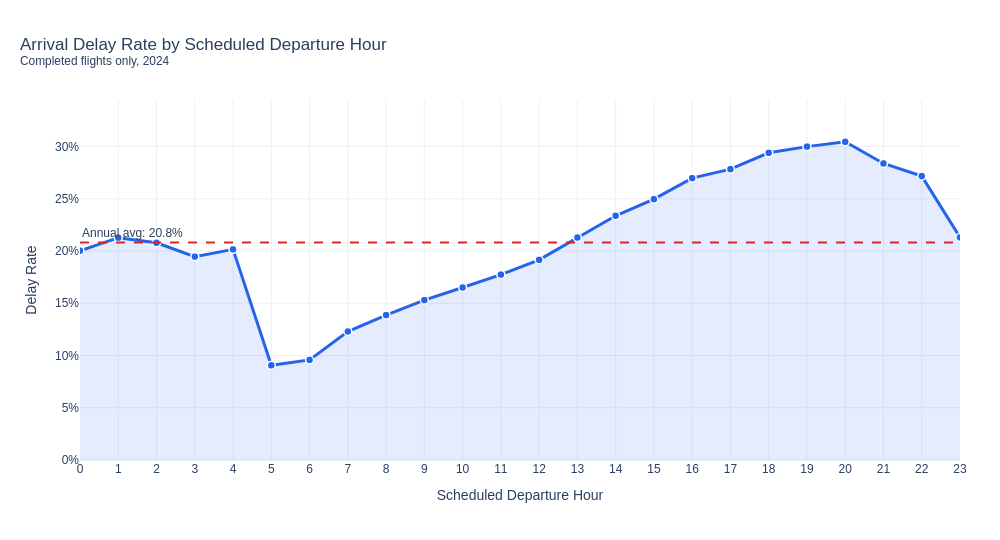

In [25]:
hourly_plot = hourly_delay.copy()
hourly_plot = hourly_plot[hourly_plot["sched_dep_hour"].between(0, 23)].copy()
hourly_plot = hourly_plot.sort_values("sched_dep_hour")

hourly_plot["hour_label"] = hourly_plot["sched_dep_hour"].astype(int).astype(str)

annual_delay_rate = completed_flights["arr_delayed_15"].mean()

fig = px.line(
    hourly_plot,
    x="hour_label",
    y="delay_rate",
    markers=True,
    title="Arrival Delay Rate by Scheduled Departure Hour",
    labels={
        "hour_label": "Scheduled Departure Hour",
        "delay_rate": "Delay Rate"
    },
    hover_data={
        "hour_label": False,
        "delay_rate": ":.1%",
        "flight_count": ":,",
        "avg_arr_delay": ":.2f"
    }
)

fig.update_traces(
    line=dict(color="#2563EB", width=3),
    marker=dict(
        size=8,
        color="#2563EB",
        line=dict(width=1.5, color="white")
    )
)

fig.add_hline(
    y=annual_delay_rate,
    line_dash="dash",
    line_color="#DC2626",
    annotation_text=f"Annual avg: {annual_delay_rate:.1%}",
    annotation_position="top left"
)

fig.update_layout(
    template="plotly_white",
    height=540,
    width=1_000,
    title=dict(
        text="Arrival Delay Rate by Scheduled Departure Hour<br><sup>Completed flights only, 2024</sup>",
        x=0.02,
        xanchor="left"
    ),
    xaxis=dict(
        title="Scheduled Departure Hour",
        categoryorder="array",
        categoryarray=[str(h) for h in range(24)],
        tickangle=0
    ),
    yaxis=dict(
        title="Delay Rate",
        tickformat=".0%",
        range=[0, hourly_plot["delay_rate"].max() + 0.04]
    ),
    hovermode="x unified",
    margin=dict(t=100, r=40, b=80, l=80)
)
fig.update_traces(fill="tozeroy", fillcolor="rgba(37, 99, 235, 0.12)")

fig.show()

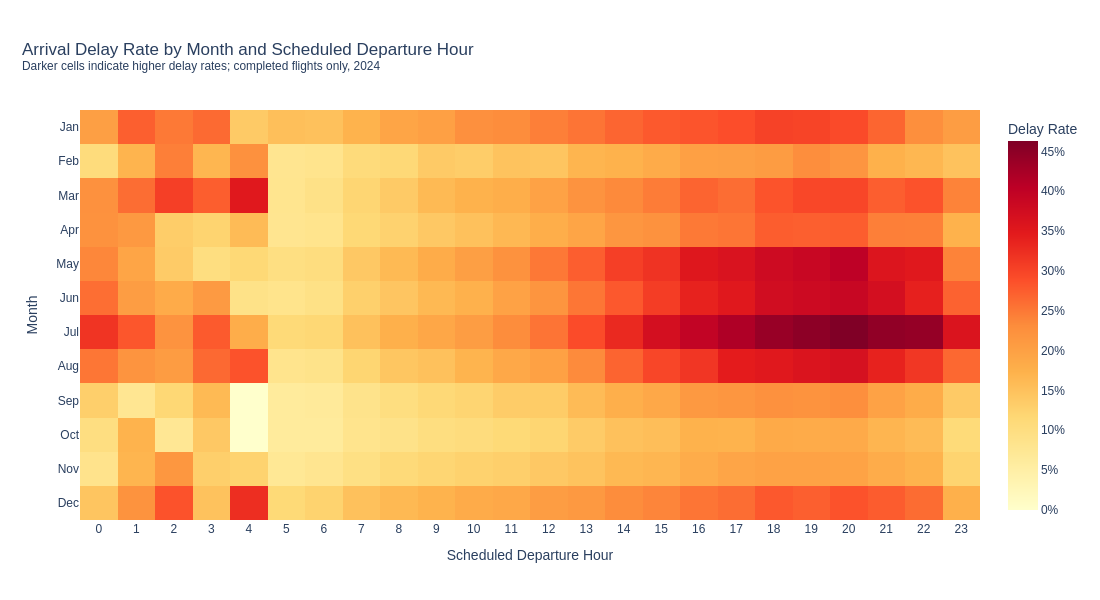

In [26]:
month_hour_delay = (
    completed_flights.groupby(["Month", "sched_dep_hour"], observed=True)
    .agg(
        delay_rate=("arr_delayed_15", "mean"),
        flight_count=("arr_delayed_15", "size"),
        avg_arr_delay=("ArrDelayMinutes", "mean")
    )
    .reset_index()
)

month_hour_delay = month_hour_delay[
    month_hour_delay["sched_dep_hour"].between(0, 23)
].copy()

month_hour_delay["month_name"] = pd.to_datetime(
    month_hour_delay["Month"], format="%m"
).dt.strftime("%b")

month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
hour_order = list(range(24))

heatmap_data = (
    month_hour_delay
    .pivot(index="month_name", columns="sched_dep_hour", values="delay_rate")
    .reindex(month_order)
)

fig = px.imshow(
    heatmap_data,
    aspect="auto",
    color_continuous_scale="YlOrRd",
    labels={"x": "Scheduled Departure Hour", "y": "Month", "color": "Delay Rate"},
    title="Arrival Delay Rate by Month and Scheduled Departure Hour"
)

fig.update_layout(
    template="plotly_white",
    height=600,
    width=1_100,
    title=dict(
        text="Arrival Delay Rate by Month and Scheduled Departure Hour<br><sup>Darker cells indicate higher delay rates; completed flights only, 2024</sup>",
        x=0.02,
        xanchor="left"
    ),
    xaxis=dict(
        title="Scheduled Departure Hour",
        tickmode="array",
        tickvals=hour_order,
        ticktext=[str(h) for h in hour_order]
    ),
    yaxis=dict(title="Month", autorange="reversed"),
    coloraxis=dict(colorbar=dict(title="Delay Rate", tickformat=".0%")),
    margin=dict(t=110, r=90, b=80, l=80)
)

fig.show()


In [27]:
weekend_delay = (
    completed_flights.groupby("is_weekend")
    .agg(
        flight_count=("arr_delayed_15", "size"),
        delay_rate=("arr_delayed_15", "mean"),
        avg_arr_delay=("ArrDelayMinutes", "mean")
    )
    .reset_index()
)

weekend_delay["day_type"] = weekend_delay["is_weekend"].map({
    0: "Weekday",
    1: "Weekend"
})

weekend_delay

,is_weekend,flight_count,delay_rate,avg_arr_delay,day_type
0,0,5037625,0.21,15.70,Weekday
1,1,1927622,0.22,16.42,Weekend


In [28]:
daily_delay = (
    completed_flights.groupby("FlightDate")
    .agg(
        flight_count=("arr_delayed_15", "size"),
        delay_rate=("arr_delayed_15", "mean"),
        avg_arr_delay=("ArrDelayMinutes", "mean")
    )
    .reset_index()
)

daily_delay.sort_values("delay_rate", ascending=False).head(15)

,FlightDate,flight_count,delay_rate,avg_arr_delay
200,2024-07-19,17886,0.58,69.69
15,2024-01-16,14384,0.51,51.91
14,2024-01-15,15563,0.50,55.54
8,2024-01-09,15263,0.45,46.41
203,2024-07-22,19567,0.45,45.50
202,2024-07-21,18941,0.41,41.26
363,2024-12-29,19777,0.41,35.76
11,2024-01-12,16570,0.39,32.91
13,2024-01-14,16129,0.39,33.44
201,2024-07-20,17039,0.38,38.91


**Insight.** Time is one of the clearest pre-flight signals. Delay rates rise from the morning into the afternoon and evening, with the highest hourly risk around the evening departure bank. Monthly patterns also show seasonality: July is the highest-delay month in this dataset, while October and November are lower-delay periods. Weekend flights are slightly higher-risk than weekdays, but the difference is modest compared with hour-of-day and seasonal effects.


### 4.3 Airline, Airport, and Route Differences


In [29]:
airline_delay = (
    completed_flights.groupby("Reporting_Airline", observed=True)
    .agg(
        flight_count=("arr_delayed_15", "size"),
        delay_rate=("arr_delayed_15", "mean"),
        avg_arr_delay=("ArrDelayMinutes", "mean")
    )
    .reset_index()
)

# Keep airlines with enough volume
airline_delay = airline_delay[airline_delay["flight_count"] >= 10_000]

airline_delay.sort_values("delay_rate", ascending=False).head(15)

,Reporting_Airline,flight_count,delay_rate,avg_arr_delay
5,F9,203482,0.29,23.83
1,AA,966116,0.26,23.44
3,B6,235683,0.26,20.97
9,NK,255633,0.24,17.72
2,AS,240323,0.22,12.44
10,OH,223673,0.22,19.18
6,G4,114882,0.22,20.09
8,MQ,275317,0.21,14.52
13,WN,1404597,0.21,12.26
12,UA,745818,0.20,15.36


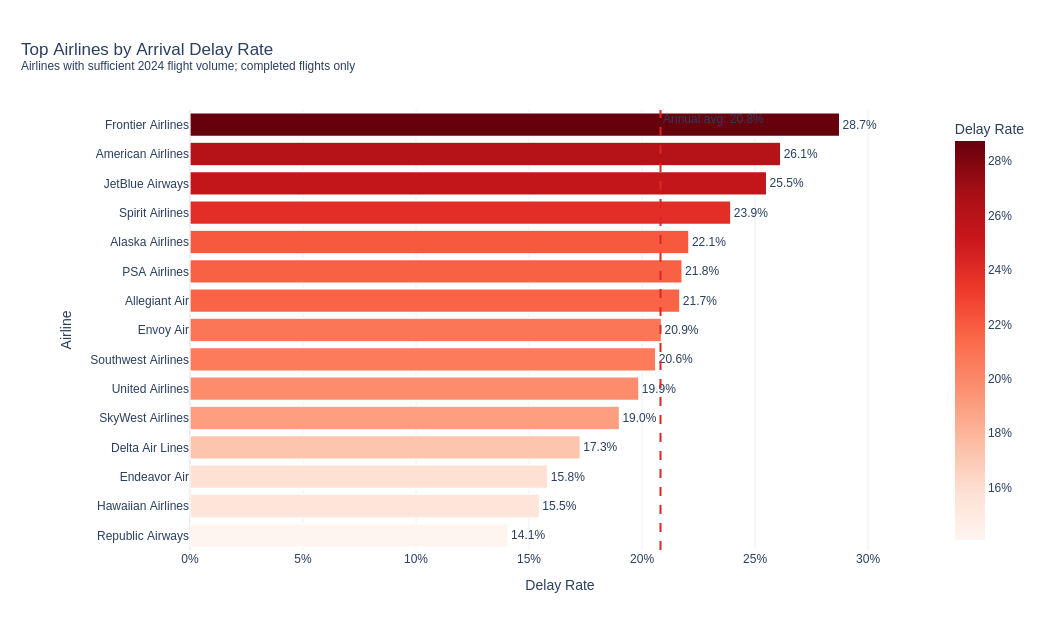

In [30]:
airline_name_map = {
    "9E": "Endeavor Air",
    "AA": "American Airlines",
    "AS": "Alaska Airlines",
    "B6": "JetBlue Airways",
    "DL": "Delta Air Lines",
    "F9": "Frontier Airlines",
    "G4": "Allegiant Air",
    "HA": "Hawaiian Airlines",
    "MQ": "Envoy Air",
    "NK": "Spirit Airlines",
    "OH": "PSA Airlines",
    "OO": "SkyWest Airlines",
    "UA": "United Airlines",
    "WN": "Southwest Airlines",
    "YX": "Republic Airways"
}

top_airline_plot = (
    airline_delay
    .sort_values("delay_rate", ascending=False)
    .head(15)
    .copy()
)

top_airline_plot["delay_rate_label"] = top_airline_plot["delay_rate"].map(lambda x: f"{x:.1%}")

top_airline_plot["airline_label"] = (
    top_airline_plot["Reporting_Airline"]
    .astype(str)
    .map(airline_name_map)
    .fillna(top_airline_plot["Reporting_Airline"].astype(str))
)

annual_delay_rate = completed_flights["arr_delayed_15"].mean()

fig = px.bar(
    top_airline_plot,
    x="delay_rate",
    y="airline_label",
    orientation="h",
    text="delay_rate_label",
    color="delay_rate",
    color_continuous_scale="Reds",
    title="Top Airlines by Arrival Delay Rate",
    labels={
        "delay_rate": "Delay Rate",
        "airline_label": "Airline"
    },
    hover_data={
        "Reporting_Airline": True,
        "airline_label": False,
        "delay_rate": ":.1%",
        "flight_count": ":,",
        "avg_arr_delay": ":.2f"
    }
)

fig.update_traces(
    textposition="outside",
    marker_line_color="white",
    marker_line_width=1.2,
    cliponaxis=False
)

fig.add_vline(
    x=annual_delay_rate,
    line_dash="dash",
    line_color="#DC2626",
    annotation_text=f"Annual avg: {annual_delay_rate:.1%}",
    annotation_position="top right"
)

fig.update_layout(
    template="plotly_white",
    height=620,
    width=1050,
    title=dict(
        text="Top Airlines by Arrival Delay Rate<br><sup>Airlines with sufficient 2024 flight volume; completed flights only</sup>",
        x=0.02,
        xanchor="left"
    ),
    xaxis=dict(
        title="Delay Rate",
        tickformat=".0%",
        range=[0, top_airline_plot["delay_rate"].max() + 0.04]
    ),
    yaxis=dict(
        title="Airline",
        categoryorder="total ascending"
    ),
    coloraxis=dict(
        colorbar=dict(
            title="Delay Rate",
            tickformat=".0%"
        )
    ),
    margin=dict(t=110, r=120, b=70, l=190)
)

fig.show()

In [31]:
origin_delay = (
    completed_flights.groupby("Origin", observed=True)
    .agg(
        flight_count=("arr_delayed_15", "size"),
        delay_rate=("arr_delayed_15", "mean"),
        avg_arr_delay=("ArrDelayMinutes", "mean")
    )
    .reset_index()
)

# Filter to meaningful airport volume
origin_delay_filtered = origin_delay[origin_delay["flight_count"] >= 20_000]

origin_delay_filtered.sort_values("delay_rate", ascending=False).head(15)

,Origin,flight_count,delay_rate,avg_arr_delay
216,MIA,107722,0.28,22.17
91,DFW,306872,0.27,21.13
69,CLT,214077,0.27,20.74
119,FLL,90121,0.27,19.89
305,SJU,34804,0.26,21.95
55,BWI,97251,0.25,15.48
204,MCO,156258,0.24,18.58
160,IAH,113248,0.24,20.14
239,ORD,275505,0.24,18.40
285,SAN,93175,0.24,16.62


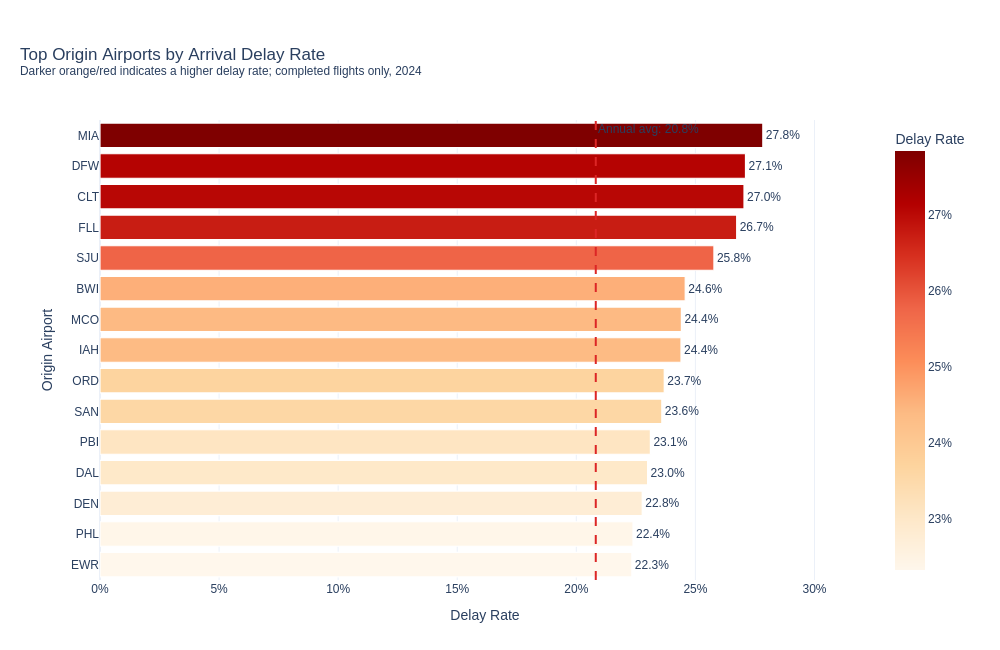

In [32]:
top_origin_plot = (
    origin_delay_filtered
    .sort_values("delay_rate", ascending=False)
    .head(15)
    .copy()
)

top_origin_plot["Origin"] = top_origin_plot["Origin"].astype(str)
top_origin_plot["delay_rate_label"] = top_origin_plot["delay_rate"].map(lambda x: f"{x:.1%}")

annual_delay_rate = completed_flights["arr_delayed_15"].mean()

fig = px.bar(
    top_origin_plot,
    x="delay_rate",
    y="Origin",
    orientation="h",
    text="delay_rate_label",
    color="delay_rate",
    color_continuous_scale="OrRd",
    title="Top Origin Airports by Arrival Delay Rate",
    labels={
        "delay_rate": "Delay Rate",
        "Origin": "Origin Airport"
    },
    hover_data={
        "Origin": False,
        "delay_rate": ":.1%",
        "flight_count": ":,",
        "avg_arr_delay": ":.2f"
    }
)

fig.update_traces(
    textposition="outside",
    marker_line_color="white",
    marker_line_width=1.2,
    cliponaxis=False
)

fig.add_vline(
    x=annual_delay_rate,
    line_dash="dash",
    line_color="#DC2626",
    annotation_text=f"Annual avg: {annual_delay_rate:.1%}",
    annotation_position="top right"
)

fig.update_layout(
    template="plotly_white",
    height=650,
    width=1_000,
    title=dict(
        text="Top Origin Airports by Arrival Delay Rate<br><sup>Darker orange/red indicates a higher delay rate; completed flights only, 2024</sup>",
        x=0.02,
        xanchor="left"
    ),
    xaxis=dict(
        title="Delay Rate",
        tickformat=".0%",
        range=[0, top_origin_plot["delay_rate"].max() + 0.045]
    ),
    yaxis=dict(
        title="Origin Airport",
        categoryorder="total ascending"
    ),
    coloraxis=dict(
        colorbar=dict(
            title="Delay Rate",
            tickformat=".0%"
        )
    ),
    margin=dict(t=120, r=130, b=70, l=100)
)

fig.show()

In [33]:
dest_delay = (
    completed_flights.groupby("Dest", observed=True)
    .agg(
        flight_count=("arr_delayed_15", "size"),
        delay_rate=("arr_delayed_15", "mean"),
        avg_arr_delay=("ArrDelayMinutes", "mean")
    )
    .reset_index()
)

dest_delay_filtered = dest_delay[dest_delay["flight_count"] >= 20_000]
dest_delay_filtered

,Dest,flight_count,delay_rate,avg_arr_delay
2,ABQ,23893,0.21,13.17
20,ATL,337684,0.17,14.20
22,AUS,84335,0.23,15.52
27,BDL,22005,0.24,16.88
41,BNA,98800,0.19,13.35
...,...,...,...,...
306,SLC,112398,0.15,12.18
308,SMF,54651,0.20,12.08
310,SNA,43045,0.17,10.90
316,STL,64844,0.19,12.53


In [34]:
route_delay = (
    completed_flights.groupby("route", observed=True)
    .agg(
        flight_count=("arr_delayed_15", "size"),
        delay_rate=("arr_delayed_15", "mean"),
        avg_arr_delay=("ArrDelayMinutes", "mean"),
        origin=("Origin", "first"),
        dest=("Dest", "first")
    )
    .reset_index()
)

route_delay_filtered = route_delay[route_delay["flight_count"] >= 1_000]

route_delay_filtered.sort_values("delay_rate", ascending=False).head(15)

,route,flight_count,delay_rate,avg_arr_delay,origin,dest
6159,SJU-PHL,1403,0.42,34.31,SJU,PHL
1239,CLT-SFO,1598,0.40,29.09,CLT,SFO
5651,SAN-SFO,6240,0.39,25.30,SAN,SFO
1891,DFW-MSN,1046,0.39,32.80,DFW,MSN
4074,MIA-SFO,1494,0.39,29.45,MIA,SFO
1903,DFW-PBI,1100,0.38,29.19,DFW,PBI
1930,DFW-SFO,3995,0.38,26.91,DFW,SFO
5010,PHL-SJU,1413,0.37,27.30,PHL,SJU
5320,PSP-SFO,2251,0.37,24.70,PSP,SFO
1919,DFW-RSW,1286,0.36,26.54,DFW,RSW


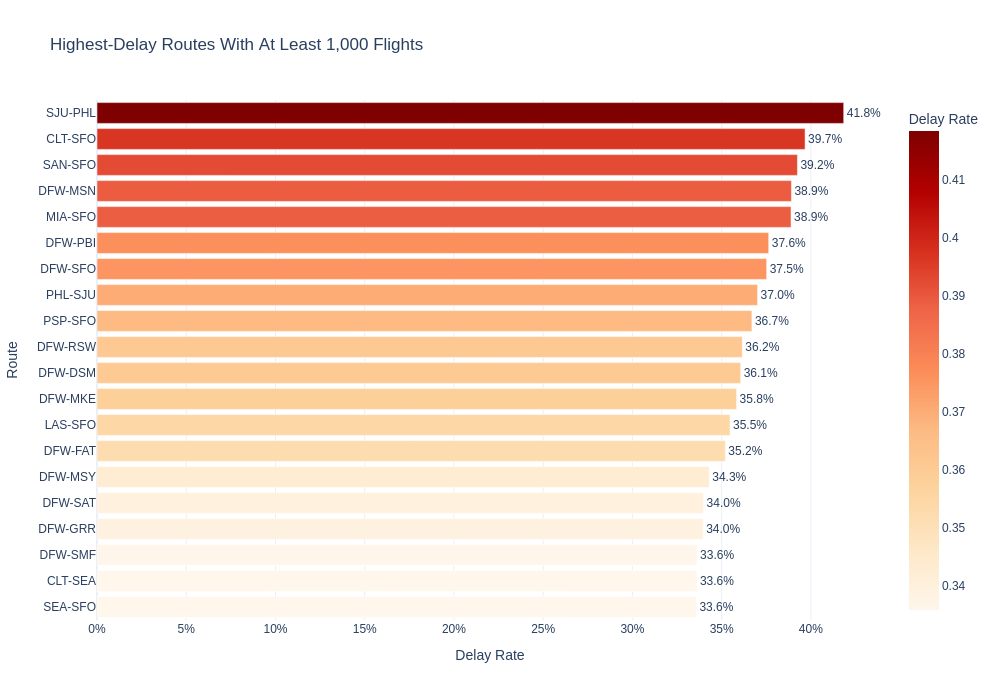

In [35]:
route_delay = (
    completed_flights.groupby(["Origin", "Dest"], observed=True)
    .agg(
        flight_count=("arr_delayed_15", "size"),
        delay_rate=("arr_delayed_15", "mean"),
        avg_arr_delay=("ArrDelayMinutes", "mean"),
        distance=("Distance", "mean")
    )
    .reset_index()
)

route_delay_filtered = route_delay[route_delay["flight_count"] >= 1_000].copy()
route_delay_filtered["route"] = route_delay_filtered["Origin"].astype(str) + "-" + route_delay_filtered["Dest"].astype(str)

top_route_plot = route_delay_filtered.sort_values("delay_rate", ascending=False).head(20)

fig = px.bar(
    top_route_plot.sort_values("delay_rate"),
    x="delay_rate",
    y="route",
    orientation="h",
    text="delay_rate",
    color="delay_rate",
    color_continuous_scale="OrRd",
    title="Highest-Delay Routes With At Least 1,000 Flights",
    labels={
        "delay_rate": "Delay Rate",
        "route": "Route"
    },
    hover_data={
        "flight_count": ":,",
        "avg_arr_delay": ":.2f",
        "distance": ":.0f"
    }
)

fig.update_traces(texttemplate="%{text:.1%}", textposition="outside", cliponaxis=False)
fig.update_layout(template="plotly_white", height=700, width=1_000, xaxis_tickformat=".0%")

fig.show()

In [36]:
# Aggregate by origin airport and scheduled departure hour

airport_hour = (
    completed_flights.groupby(["Origin", "sched_dep_hour"], observed=True)
    .agg(
        flight_count=("arr_delayed_15", "size"),
        delay_rate=("arr_delayed_15", "mean"),
        avg_arr_delay=("ArrDelayMinutes", "mean")
    )
    .reset_index()
)

# Keep airports with meaningful total annual volume, not necessarily 100 flights every hour
airport_volume = (
    completed_flights.groupby("Origin", observed=True)
    .size()
    .reset_index(name="annual_flight_count")
)

airport_hour = airport_hour.merge(airport_volume, on="Origin", how="left")

airport_hour = airport_hour[airport_hour["annual_flight_count"] >= 20_000].copy()

# Ensure hour is numeric and sorted
airport_hour["sched_dep_hour"] = airport_hour["sched_dep_hour"].astype(int)
airport_hour = airport_hour.sort_values(["sched_dep_hour", "Origin"])

# Ordered animation label
airport_hour["hour_label"] = airport_hour["sched_dep_hour"].map(lambda h: f"{h:02d}:00")

hour_order = [f"{h:02d}:00" for h in range(24)]
airport_hour["hour_label"] = pd.Categorical(
    airport_hour["hour_label"],
    categories=hour_order,
    ordered=True
)

In [37]:
airport_lookup = pd.read_csv(
    "https://raw.githubusercontent.com/davidmegginson/ourairports-data/main/airports.csv"
)

airport_lookup = airport_lookup[
    ["iata_code", "name", "latitude_deg", "longitude_deg", "municipality", "iso_region"]
].dropna(subset=["iata_code"])

airport_lookup = airport_lookup.rename(columns={"iata_code": "Origin"})

airport_hour = airport_hour.merge(
    airport_lookup,
    on="Origin",
    how="left"
).dropna(subset=["latitude_deg", "longitude_deg"])

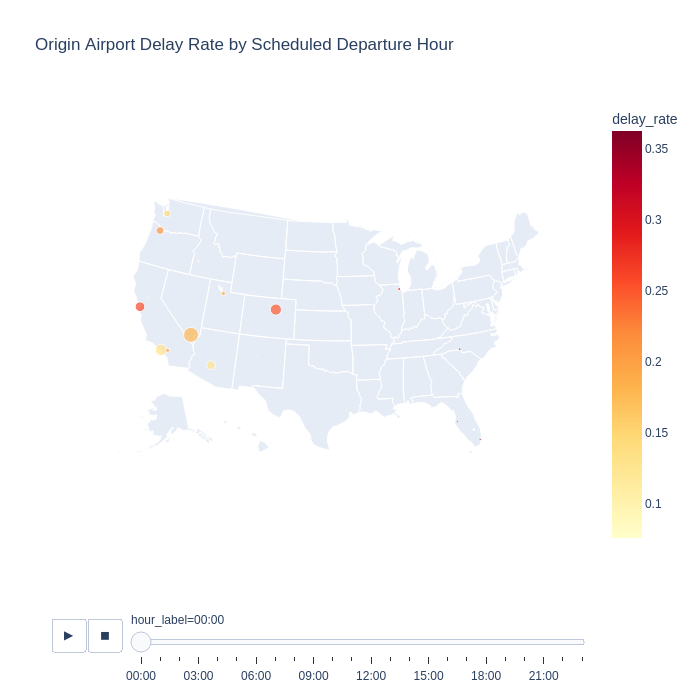

In [38]:
fig = px.scatter_geo(
    airport_hour,
    lat="latitude_deg",
    lon="longitude_deg",
    scope="usa",
    animation_frame="hour_label",
    color="delay_rate",
    size="flight_count",
    hover_name="Origin",
    hover_data={
        "name": True,
        "municipality": True,
        "flight_count": ":,",
        "annual_flight_count": ":,",
        "delay_rate": ":.1%",
        "avg_arr_delay": ":.2f",
        "latitude_deg": False,
        "longitude_deg": False
    },
    color_continuous_scale="YlOrRd",
    range_color=[
        airport_hour["delay_rate"].quantile(0.05),
        airport_hour["delay_rate"].quantile(0.95)
    ],
    size_max=35,
    category_orders={"hour_label": hour_order},
    title="Origin Airport Delay Rate by Scheduled Departure Hour"
)

fig.update_layout(height=700)
fig.show()

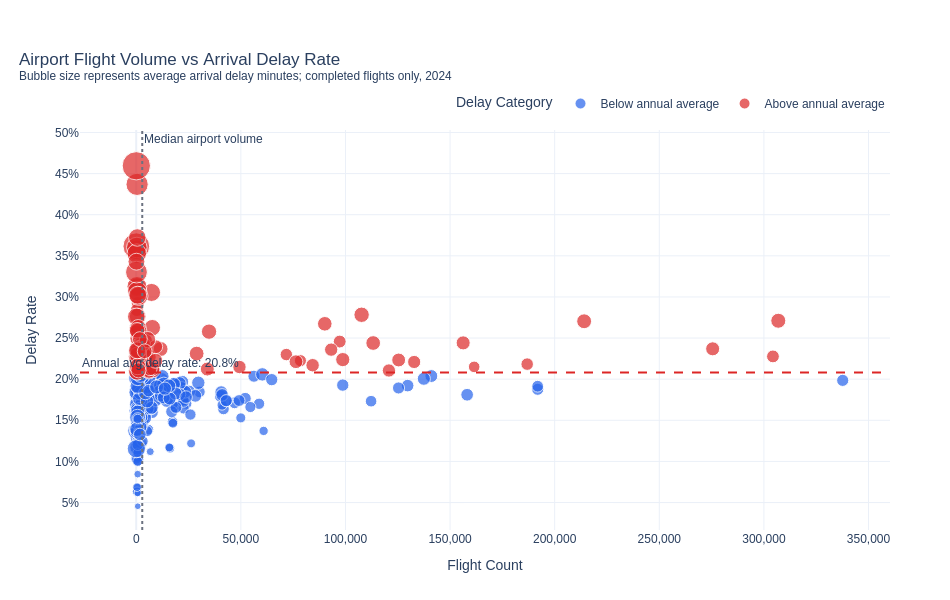

In [39]:
airport_volume_delay = origin_delay.copy()
annual_delay_rate = completed_flights["ArrDel15"].mean()
median_airport_volume = airport_volume_delay["flight_count"].median()

airport_volume_delay["delay_category"] = np.where(
    airport_volume_delay["delay_rate"] >= annual_delay_rate,
    "Above annual average",
    "Below annual average"
)

fig = px.scatter(
    airport_volume_delay,
    x="flight_count",
    y="delay_rate",
    size="avg_arr_delay",
    color="delay_category",
    hover_name="Origin",
    title="Airport Flight Volume vs Arrival Delay Rate",
    labels={
        "flight_count": "Flight Count",
        "delay_rate": "Delay Rate",
        "avg_arr_delay": "Avg Arrival Delay",
        "delay_category": "Delay Category"
    },
    hover_data={
        "flight_count": ":,",
        "delay_rate": ":.1%",
        "avg_arr_delay": ":.2f"
    },
    color_discrete_map={
        "Above annual average": "#DC2626",
        "Below annual average": "#2563EB"
    }
)

fig.add_hline(
    y=annual_delay_rate,
    line_dash="dash",
    line_color="#DC2626",
    annotation_text=f"Annual avg delay rate: {annual_delay_rate:.1%}",
    annotation_position="top left"
)

fig.add_vline(
    x=median_airport_volume,
    line_dash="dot",
    line_color="#6B7280",
    annotation_text="Median airport volume",
    annotation_position="top right"
)

fig.update_layout(
    template="plotly_white",
    height=600,
    width=950,
    title=dict(
        text="Airport Flight Volume vs Arrival Delay Rate<br><sup>Bubble size represents average arrival delay minutes; completed flights only, 2024</sup>",
        x=0.02,
        xanchor="left"
    ),
    xaxis=dict(
        title="Flight Count",
        tickformat=","
    ),
    yaxis=dict(
        title="Delay Rate",
        tickformat=".0%"
    ),
    legend=dict(
        title="Delay Category",
        orientation="h",
        yanchor="bottom",
        y=1.03,
        xanchor="right",
        x=1
    ),
    margin=dict(t=130, r=60, b=70, l=80)
)

fig.show()

**Insight.** Delay rates differ across airlines, origin airports, destination airports, and routes even after filtering to sufficiently large flight volumes. The airport map and volume-vs-delay chart show that large airports are not automatically the highest-delay airports; both operational scale and airport-specific conditions matter. These patterns support including carrier, origin, destination, route, distance, and airport-size features in modeling.


### 4.4 Holiday Effects


In [40]:
holiday_delay = (
    completed_flights.groupby("is_holiday")
    .agg(
        flight_count=("ArrDel15", "size"),
        delay_rate=("ArrDel15", "mean"),
        avg_arr_delay=("ArrDelayMinutes", "mean")
    )
    .reset_index()
)

holiday_delay["holiday_type"] = holiday_delay["is_holiday"].map({
    0: "Non-Holiday",
    1: "Federal Holiday"
})

holiday_delay

,is_holiday,flight_count,delay_rate,avg_arr_delay,holiday_type
0,0,6766981,0.21,15.91,Non-Holiday
1,1,198266,0.19,15.33,Federal Holiday


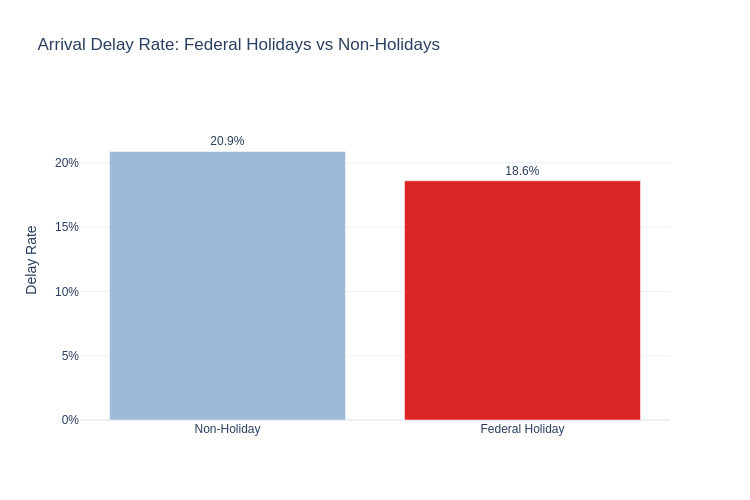

In [41]:
fig = px.bar(
    holiday_delay,
    x="holiday_type",
    y="delay_rate",
    text="delay_rate",
    color="holiday_type",
    title="Arrival Delay Rate: Federal Holidays vs Non-Holidays",
    labels={
        "holiday_type": "",
        "delay_rate": "Delay Rate"
    },
    hover_data={
        "flight_count": ":,",
        "delay_rate": ":.1%",
        "avg_arr_delay": ":.2f"
    },
    color_discrete_map={
        "Non-Holiday": "#9DBBD8",
        "Federal Holiday": "#DC2626"
    }
)

fig.update_traces(texttemplate="%{text:.1%}", textposition="outside")
fig.update_layout(
    template="plotly_white",
    height=500,
    width=750,
    yaxis=dict(tickformat=".0%", range=[0, holiday_delay["delay_rate"].max() + 0.04]),
    showlegend=False
)

fig.show()

In [42]:
holiday_window_delay = (
    completed_flights.groupby("is_holiday_week")
    .agg(
        flight_count=("ArrDel15", "size"),
        delay_rate=("ArrDel15", "mean"),
        avg_arr_delay=("ArrDelayMinutes", "mean")
    )
    .reset_index()
)

holiday_window_delay["period_type"] = holiday_window_delay["is_holiday_week"].map({
    0: "Normal Days",
    1: "Within +/- 2 Days of Holiday"
})

holiday_window_delay

,is_holiday_week,flight_count,delay_rate,avg_arr_delay,period_type
0,0,5990101,0.21,15.98,Normal Days
1,1,975146,0.20,15.36,Within +/- 2 Days of Holiday


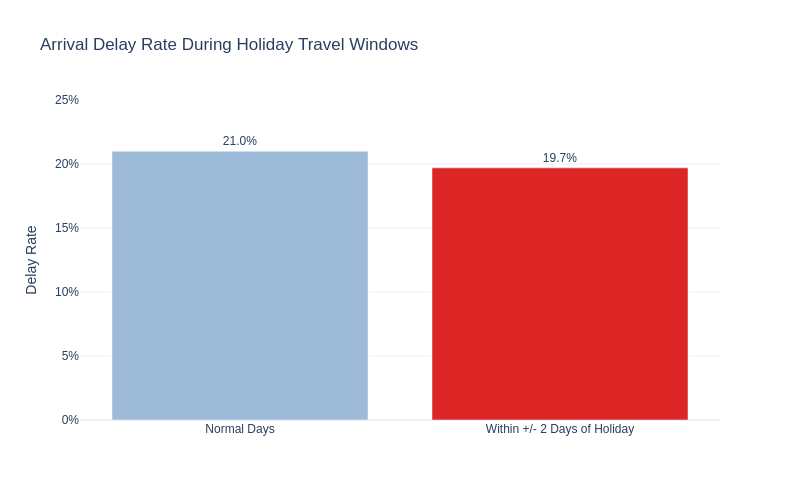

In [43]:
fig = px.bar(
    holiday_window_delay,
    x="period_type",
    y="delay_rate",
    text="delay_rate",
    color="period_type",
    title="Arrival Delay Rate During Holiday Travel Windows",
    labels={
        "period_type": "",
        "delay_rate": "Delay Rate"
    },
    hover_data={
        "flight_count": ":,",
        "delay_rate": ":.1%",
        "avg_arr_delay": ":.2f"
    },
    color_discrete_map={
        "Normal Days": "#9DBBD8",
        "Within +/- 2 Days of Holiday": "#DC2626"
    }
)

fig.update_traces(texttemplate="%{text:.1%}", textposition="outside")
fig.update_layout(
    template="plotly_white",
    height=500,
    width=800,
    yaxis=dict(tickformat=".0%", range=[0, holiday_window_delay["delay_rate"].max() + 0.04]),
    showlegend=False
)

fig.show()

In [44]:
us_holidays = holidays.US(years=[2024])
holiday_name_map = {pd.Timestamp(k): v for k, v in us_holidays.items()}

completed_flights["holiday_name"] = (
    completed_flights["FlightDate"]
    .dt.normalize()
    .map(holiday_name_map)
    .fillna("Non-Holiday")
)

holiday_name_delay = (
    completed_flights[completed_flights["holiday_name"] != "Non-Holiday"]
    .groupby("holiday_name")
    .agg(
        flight_count=("ArrDel15", "size"),
        delay_rate=("ArrDel15", "mean"),
        avg_arr_delay=("ArrDelayMinutes", "mean")
    )
    .reset_index()
    .sort_values("delay_rate", ascending=False)
)

holiday_name_delay

,holiday_name,flight_count,delay_rate,avg_arr_delay
5,Martin Luther King Jr. Day,15563,0.50,55.54
6,Memorial Day,19983,0.32,28.65
3,Juneteenth National Independence Day,20189,0.20,13.17
4,Labor Day,20507,0.18,13.70
10,Washington's Birthday,19006,0.17,11.66
1,Columbus Day,21375,0.16,11.61
7,New Year's Day,17241,0.11,8.03
9,Veterans Day,20737,0.11,7.35
2,Independence Day,16903,0.10,6.97
0,Christmas Day,15561,0.09,7.18


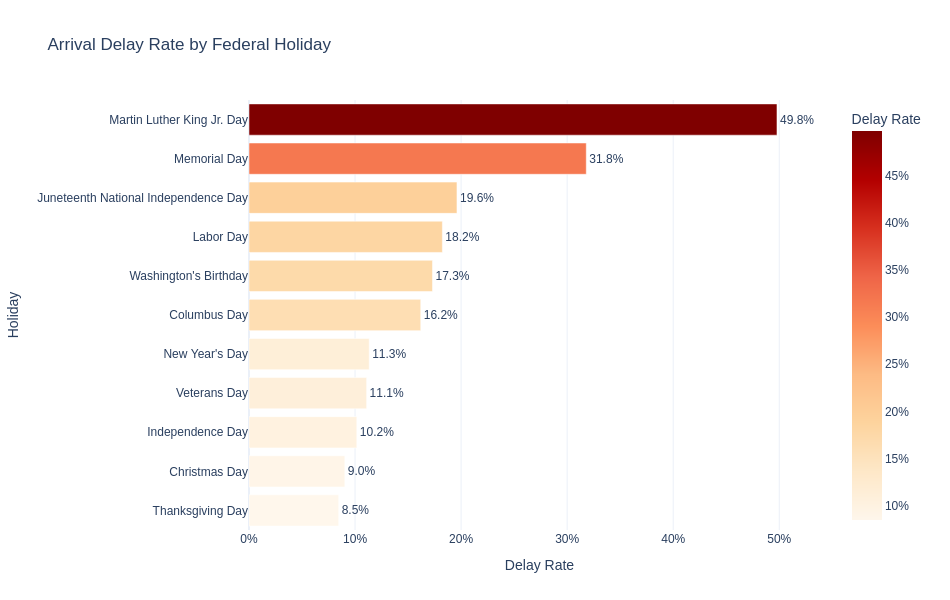

In [45]:
fig = px.bar(
    holiday_name_delay.sort_values("delay_rate"),
    x="delay_rate",
    y="holiday_name",
    orientation="h",
    text="delay_rate",
    color="delay_rate",
    color_continuous_scale="OrRd",
    title="Arrival Delay Rate by Federal Holiday",
    labels={
        "delay_rate": "Delay Rate",
        "holiday_name": "Holiday"
    },
    hover_data={
        "flight_count": ":,",
        "delay_rate": ":.1%",
        "avg_arr_delay": ":.2f"
    }
)

fig.update_traces(texttemplate="%{text:.1%}", textposition="outside", cliponaxis=False)
fig.update_layout(
    template="plotly_white",
    height=600,
    width=950,
    xaxis=dict(tickformat=".0%", range=[0, holiday_name_delay["delay_rate"].max() + 0.05]),
    coloraxis_colorbar=dict(title="Delay Rate", tickformat=".0%"),
    margin=dict(t=100, r=120, b=70, l=220)
)

fig.show()

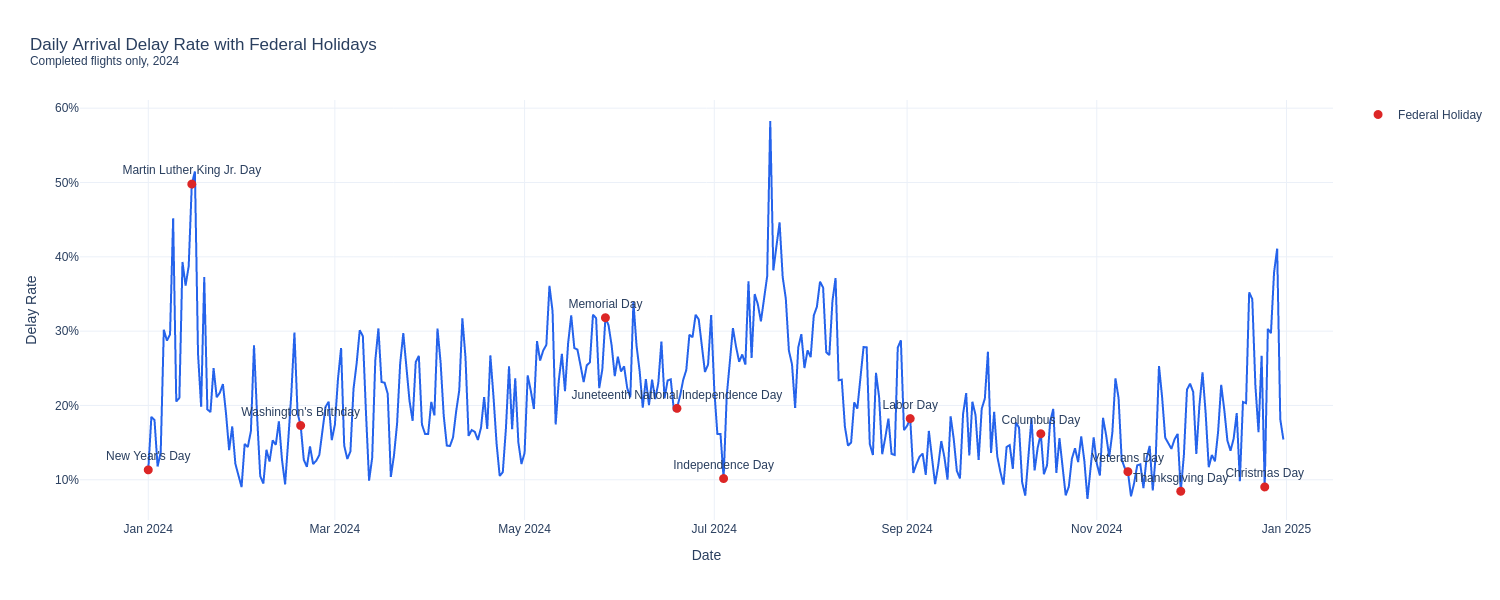

In [46]:
daily_delay = (
    completed_flights.groupby("FlightDate")
    .agg(
        flight_count=("ArrDel15", "size"),
        delay_rate=("ArrDel15", "mean"),
        avg_arr_delay=("ArrDelayMinutes", "mean")
    )
    .reset_index()
)

daily_delay["holiday_name"] = daily_delay["FlightDate"].dt.normalize().map(holiday_name_map)
daily_delay["is_holiday"] = daily_delay["holiday_name"].notna()

fig = px.line(
    daily_delay,
    x="FlightDate",
    y="delay_rate",
    title="Daily Arrival Delay Rate with Federal Holidays",
    labels={
        "FlightDate": "Date",
        "delay_rate": "Delay Rate"
    },
    hover_data={
        "delay_rate": ":.1%",
        "flight_count": ":,",
        "avg_arr_delay": ":.2f"
    }
)

fig.update_traces(line=dict(color="#2563EB", width=2))

holiday_points = daily_delay[daily_delay["is_holiday"]]

fig.add_scatter(
    x=holiday_points["FlightDate"],
    y=holiday_points["delay_rate"],
    mode="markers+text",
    marker=dict(size=9, color="#DC2626"),
    text=holiday_points["holiday_name"],
    textposition="top center",
    name="Federal Holiday",
    hovertemplate="%{text}<br>%{x}<br>Delay rate: %{y:.1%}<extra></extra>"
)

fig.update_layout(
    template="plotly_white",
    height=600,
    width=1_500,
    title=dict(
        text="Daily Arrival Delay Rate with Federal Holidays<br><sup>Completed flights only, 2024</sup>",
        x=0.02,
        xanchor="left"
    ),
    yaxis=dict(tickformat=".0%"),
    hovermode="x unified"
)

fig.show()

**Insight.** Exact federal holidays are not uniformly higher-delay days. Some holidays, such as Martin Luther King Jr. Day and Memorial Day in this dataset, show elevated delay rates, while others such as Thanksgiving Day and Christmas Day are lower. The broader holiday-window feature is still useful because travel behavior often shifts to the days before and after the holiday itself.


### 4.5 Distance, Delay Causes, and Operational Relationships


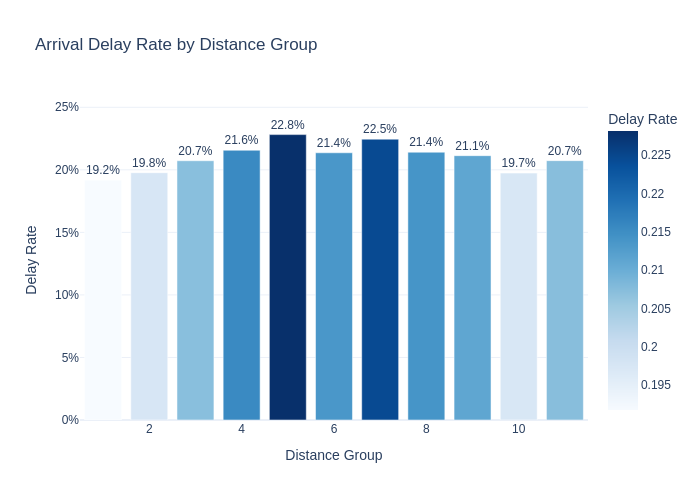

In [47]:
distance_delay = (
    completed_flights.groupby("DistanceGroup", observed=True)
    .agg(
        flight_count=("arr_delayed_15", "size"),
        delay_rate=("arr_delayed_15", "mean"),
        avg_arr_delay=("ArrDelayMinutes", "mean")
    )
    .reset_index()
)

fig = px.bar(
    distance_delay,
    x="DistanceGroup",
    y="delay_rate",
    text="delay_rate",
    title="Arrival Delay Rate by Distance Group",
    labels={
        "DistanceGroup": "Distance Group",
        "delay_rate": "Delay Rate"
    },
    hover_data={
        "flight_count": ":,",
        "delay_rate": ":.1%",
        "avg_arr_delay": ":.2f"
    },
    color="delay_rate",
    color_continuous_scale="Blues"
)

fig.update_traces(texttemplate="%{text:.1%}", textposition="outside")
fig.update_layout(template="plotly_white", yaxis_tickformat=".0%", coloraxis_showscale=True)

fig.show()

In [48]:
delay_cause_cols = [
    "CarrierDelay", "WeatherDelay", "NASDelay",
    "SecurityDelay", "LateAircraftDelay"
]

delay_causes = (
    completed_flights[delay_cause_cols]
    .sum()
    .sort_values(ascending=False)
    .to_frame("total_delay_minutes")
)

delay_causes["share"] = delay_causes["total_delay_minutes"] / delay_causes["total_delay_minutes"].sum()

delay_causes

,total_delay_minutes,share
LateAircraftDelay,"41,973,672.00",0.40
CarrierDelay,"35,823,248.00",0.35
NASDelay,"19,621,972.00",0.19
WeatherDelay,"6,195,873.00",0.06
SecurityDelay,"179,928.00",0.00


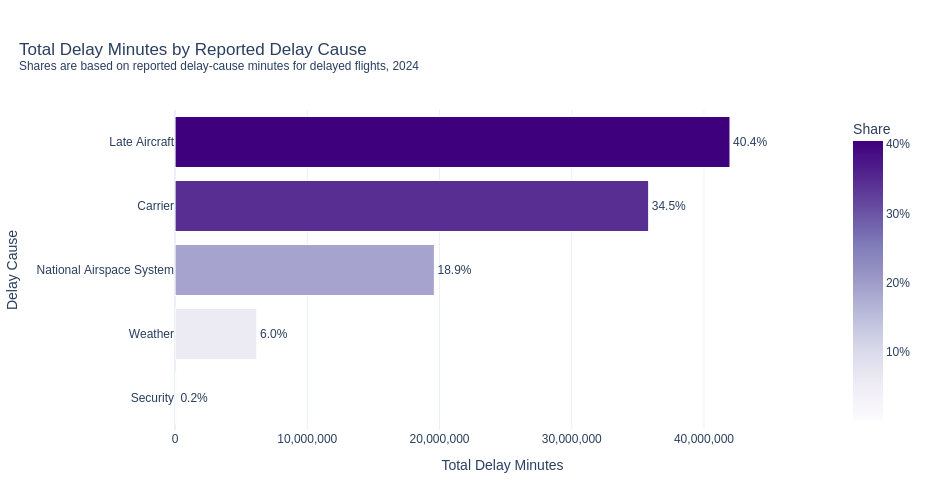

In [49]:
delay_causes_plot = delay_causes.reset_index().copy()
delay_causes_plot = delay_causes_plot.rename(columns={"index": "delay_cause"})

# Cleaner labels
cause_name_map = {
    "CarrierDelay": "Carrier",
    "WeatherDelay": "Weather",
    "NASDelay": "National Airspace System",
    "SecurityDelay": "Security",
    "LateAircraftDelay": "Late Aircraft"
}

delay_causes_plot["delay_cause"] = delay_causes_plot["delay_cause"].replace(cause_name_map)
delay_causes_plot["share_label"] = delay_causes_plot["share"].map(lambda x: f"{x:.1%}")

fig = px.bar(
    delay_causes_plot.sort_values("total_delay_minutes", ascending=True),
    x="total_delay_minutes",
    y="delay_cause",
    orientation="h",
    text="share_label",
    color="share",
    color_continuous_scale="Purples",
    title="Total Delay Minutes by Reported Delay Cause",
    labels={
        "total_delay_minutes": "Total Delay Minutes",
        "delay_cause": "Delay Cause",
        "share": "Share of Delay Minutes"
    },
    hover_data={
        "delay_cause": False,
        "total_delay_minutes": ":,",
        "share": ":.1%"
    }
)

fig.update_traces(
    textposition="outside",
    marker_line_color="white",
    marker_line_width=1.2,
    cliponaxis=False
)

fig.update_layout(
    template="plotly_white",
    height=500,
    width=950,
    title=dict(
        text="Total Delay Minutes by Reported Delay Cause<br><sup>Shares are based on reported delay-cause minutes for delayed flights, 2024</sup>",
        x=0.02,
        xanchor="left"
    ),
    xaxis=dict(
        title="Total Delay Minutes",
        tickformat=",",
        range=[0, delay_causes_plot["total_delay_minutes"].max() * 1.18]
    ),
    yaxis=dict(title="Delay Cause"),
    coloraxis=dict(
        colorbar=dict(
            title="Share",
            tickformat=".0%"
        )
    ),
    margin=dict(t=110, r=120, b=70, l=170)
)

fig.show()

In [50]:
completed_flights["delay_recovered_minutes"] = (
    completed_flights["DepDelayMinutes"] - completed_flights["ArrDelayMinutes"]
)

completed_flights["delay_recovered_minutes"].describe()

,delay_recovered_minutes
count,"6,965,247.00"
mean,-0.01
std,10.33
min,-639.00
25%,0.00
50%,0.00
75%,1.00
max,492.00


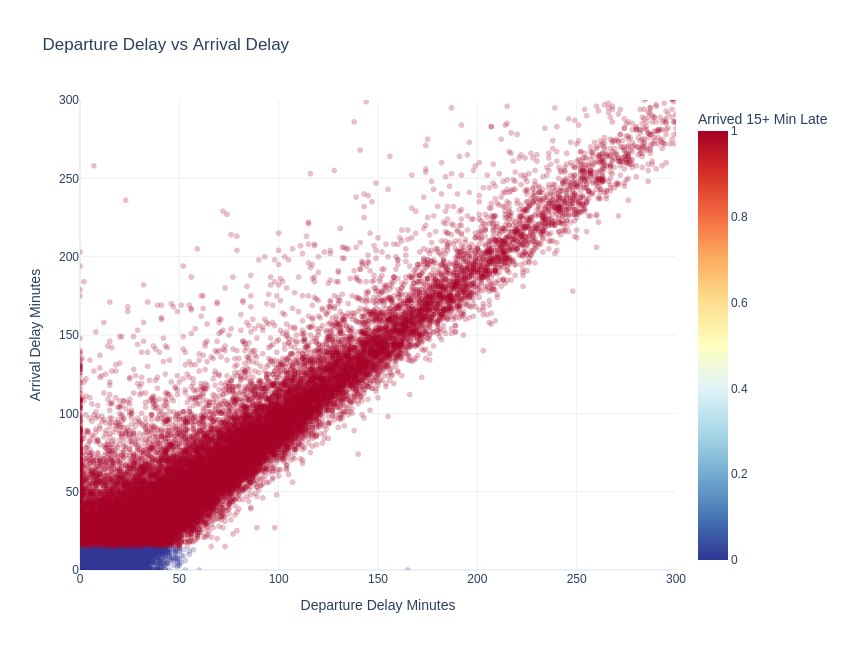

In [51]:
sample_df = completed_flights.sample(n=200_000, random_state=42)

fig = px.scatter(
    sample_df,
    x="DepDelayMinutes",
    y="ArrDelayMinutes",
    color="arr_delayed_15",
    opacity=0.25,
    title="Departure Delay vs Arrival Delay",
    labels={
        "DepDelayMinutes": "Departure Delay Minutes",
        "ArrDelayMinutes": "Arrival Delay Minutes",
        "arr_delayed_15": "Arrived 15+ Min Late"
    },
    color_continuous_scale="RdYlBu_r"
)

fig.update_layout(
    template="plotly_white",
    height=650,
    width=850,
    xaxis=dict(range=[0, 300]),
    yaxis=dict(range=[0, 300])
)

fig.show()

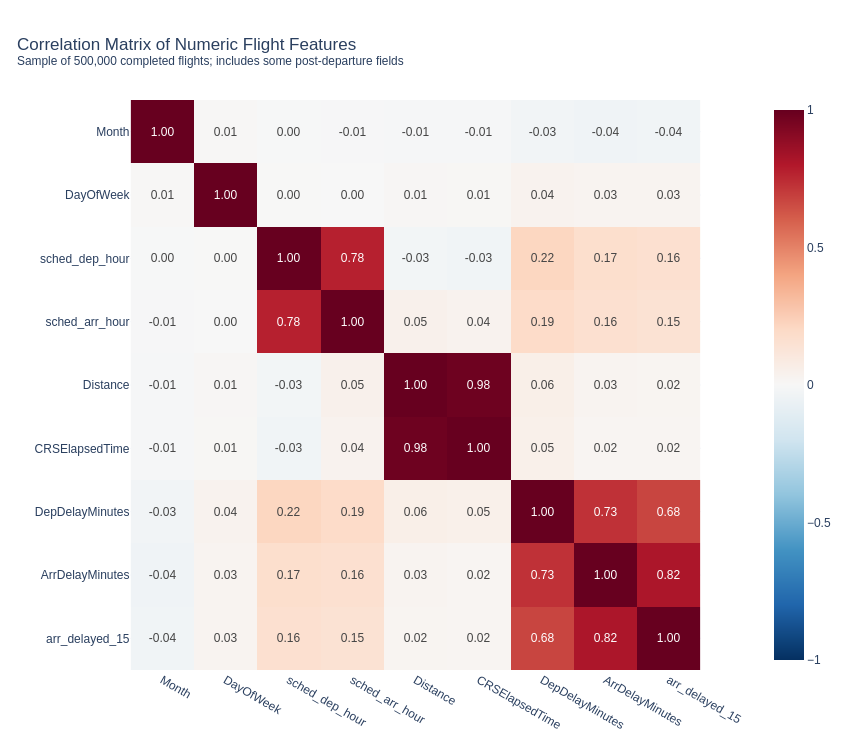

In [52]:
corr_cols = [
    "Month",
    "DayOfWeek",
    "sched_dep_hour",
    "sched_arr_hour",
    "Distance",
    "CRSElapsedTime",
    "DepDelayMinutes",
    "ArrDelayMinutes",
    "arr_delayed_15"
]

corr_df = completed_flights[corr_cols].sample(
    n=500_000,
    random_state=42
)

corr_matrix = corr_df.corr(method="spearman")

fig = px.imshow(
    corr_matrix,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1,
    title="Correlation Matrix of Numeric Flight Features"
)

fig.update_layout(
    template="plotly_white",
    height=750,
    width=850,
    title=dict(
        text="Correlation Matrix of Numeric Flight Features<br><sup>Sample of 500,000 completed flights; includes some post-departure fields</sup>",
        x=0.02,
        xanchor="left"
    ),
    margin=dict(t=100, r=80, b=80, l=80)
)

fig.show()

**Insight.** Distance group has a smaller relationship with delay risk than schedule timing, but it may still help a model capture differences between short-haul and long-haul operations. Delay-cause fields are useful for interpretation after delays occur, but they should not be used as pre-flight predictors. Departure delay is strongly related to arrival delay and is appropriate for a separate post-departure model, not for a strict pre-flight model.


### 4.6 Modeling-Oriented Correlation Check


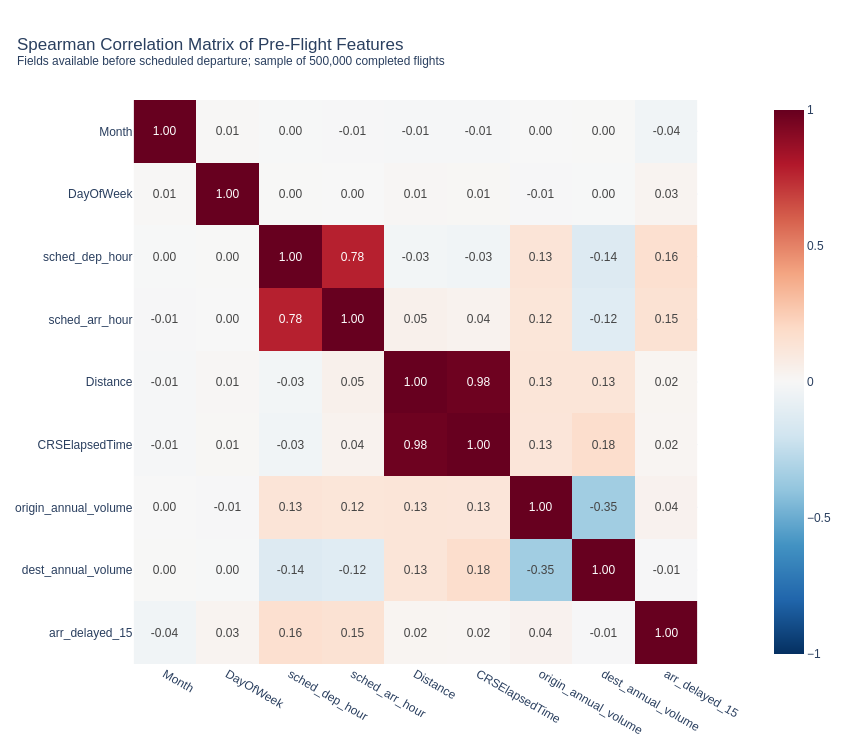

In [53]:
# Spearman correlation among fields available before departure.
# Exclude actual departure, actual arrival, delay-cause fields, and the post-outcome ArrDelayMinutes.
preflight_corr_cols = [
    "Month",
    "DayOfWeek",
    "sched_dep_hour",
    "sched_arr_hour",
    "Distance",
    "CRSElapsedTime",
    "origin_annual_volume",
    "dest_annual_volume",
    "arr_delayed_15"
]

preflight_corr = (
    completed_flights[preflight_corr_cols]
    .sample(n=500_000, random_state=42)
    .corr(method="spearman")
)

fig = px.imshow(
    preflight_corr,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1,
    title="Spearman Correlation Matrix of Pre-Flight Features"
)

fig.update_layout(
    template="plotly_white",
    height=750,
    width=850,
    title=dict(
        text="Spearman Correlation Matrix of Pre-Flight Features<br><sup>Fields available before scheduled departure; sample of 500,000 completed flights</sup>",
        x=0.02,
        xanchor="left"
    ),
    margin=dict(t=100, r=80, b=80, l=80)
)

fig.show()


**Insight.** The pre-flight correlation matrix shows modest individual correlations with the binary delay target. This is expected: delay risk depends on nonlinear effects and interactions across month, hour, airport, airline, and route. The month-hour heatmap and airport/route charts show useful structure that simple pairwise correlation does not capture. For this reason, tree-based models or models with interaction features are likely to be more informative than a purely linear model.


## 5. Modeling-Ready Takeaways

Recommended first pre-flight feature set:
- Time: `Month`, `DayOfWeek`, `sched_dep_hour`, `sched_arr_hour`, `is_weekend`, `is_holiday`, `is_holiday_week`
- Carrier and network: `Reporting_Airline`, `Origin`, `Dest`, `route`
- Flight characteristics: `Distance`, `DistanceGroup`, `CRSElapsedTime`
- Airport scale/congestion: `origin_annual_volume`, `dest_annual_volume`, optional `origin_hourly_departure_volume`

Fields to exclude from a pre-flight model to avoid leakage:
- Actual operations: `DepTime`, `DepDelayMinutes`, `DepDel15`, `ArrTime`, `ActualElapsedTime`, `AirTime`
- Target/outcome fields: `ArrDelayMinutes`, `ArrDel15` except as the source of the target, `arr_delayed_15` except as `y`
- Delay-cause fields: `CarrierDelay`, `WeatherDelay`, `NASDelay`, `SecurityDelay`, `LateAircraftDelay`

A second model could be framed as a post-departure model that uses departure delay to predict arrival delay risk after the flight has departed. That model should be clearly separated from the pre-flight model.


## 6. Modeling: Predicting 15+ Minute Arrival Delay

The modeling task is framed as a **pre-flight binary classification problem**: predict whether a completed flight will arrive 15 or more minutes late using only fields that are available before scheduled departure.

To make validation realistic, model selection uses **rolling monthly cross-validation** on earlier months, then keeps October-December as a final future holdout test. This is stricter than random K-fold because it evaluates whether a model trained on earlier flights generalizes to later flights.


### 6.1 Modeling Dataset and Leakage Rules

The target is `arr_delayed_15`. The predictors include schedule timing, carrier, airports, route, distance, holiday flags, and airport-size features.

Excluded from the pre-flight model:
- Actual operations: `DepTime`, `DepDelayMinutes`, `DepDel15`, `ArrTime`, `ActualElapsedTime`, `AirTime`
- Outcome fields: `ArrDelayMinutes`, `ArrDel15` except as the source of the target
- Delay-cause fields: `CarrierDelay`, `WeatherDelay`, `NASDelay`, `SecurityDelay`, `LateAircraftDelay`


In [54]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

# Make sure the target exists after notebook restarts / reloads
if "arr_delayed_15" not in completed_flights.columns:
    completed_flights["arr_delayed_15"] = completed_flights["ArrDel15"].astype("int8")

# Ensure engineered features exist if cells above were skipped
if "route" not in completed_flights.columns:
    completed_flights["route"] = completed_flights["Origin"].astype(str) + "-" + completed_flights["Dest"].astype(str)

if "is_weekend" not in completed_flights.columns:
    completed_flights["is_weekend"] = completed_flights["DayOfWeek"].isin([6, 7]).astype("int8")

for col in ["is_holiday", "is_holiday_week"]:
    if col not in completed_flights.columns:
        completed_flights[col] = 0

# Airport size features are useful
if "origin_annual_volume" not in completed_flights.columns:
    origin_size = completed_flights.groupby("Origin", observed=True).size().reset_index(name="origin_annual_volume")
    completed_flights = completed_flights.merge(origin_size, on="Origin", how="left")

if "dest_annual_volume" not in completed_flights.columns:
    dest_size = completed_flights.groupby("Dest", observed=True).size().reset_index(name="dest_annual_volume")
    completed_flights = completed_flights.merge(dest_size, on="Dest", how="left")


In [55]:
target = "arr_delayed_15"

numeric_features = [
    "sched_dep_hour",
    "sched_arr_hour",
    "Distance",
    "CRSElapsedTime",
    "origin_annual_volume",
    "dest_annual_volume",
    "is_weekend",
    "is_holiday",
    "is_holiday_week"
]

categorical_features = [
    "Month",
    "DayOfWeek",
    "Reporting_Airline",
    "Origin",
    "Dest",
    "route",
    "DistanceGroup"
]

model_cols = ["FlightDate", target] + numeric_features + categorical_features

model_df = completed_flights[model_cols].dropna().copy()
model_df["FlightDate"] = pd.to_datetime(model_df["FlightDate"])

# Use a sample for fast, repeatable model comparison in Colab.

MODEL_SAMPLE_SIZE = 500_000

model_base = completed_flights[model_cols].dropna().copy()

model_base["strata"] = (
    model_base[target].astype(str) + "_" +
    model_base["Month"].astype(str) + "_" +
    model_base["sched_dep_hour"].astype(str)
)

sample_frac = MODEL_SAMPLE_SIZE / len(model_base)

# First proportional stratified sample
model_df = (
    model_base
    .groupby("strata", group_keys=False)
    .apply(lambda x: x.sample(
        n=max(1, int(round(len(x) * sample_frac))),
        random_state=42
    ))
    .copy()
)

# If rounding created too many rows, trim down
if len(model_df) > MODEL_SAMPLE_SIZE:
    model_df = model_df.sample(n=MODEL_SAMPLE_SIZE, random_state=42)

# If rounding created too few rows, top up from unsampled rows
elif len(model_df) < MODEL_SAMPLE_SIZE:
    shortfall = MODEL_SAMPLE_SIZE - len(model_df)

    remaining = model_base.drop(index=model_df.index)

    top_up = remaining.sample(
        n=shortfall,
        random_state=42
    )

    model_df = pd.concat([model_df, top_up], axis=0)

model_df = (
    model_df
    .drop(columns="strata")
    .sort_values("FlightDate")
    .reset_index(drop=True)
)

print("Modeling dataset shape:", model_df.shape)
print("Target rate:", f"{model_df[target].mean():.2%}")

/tmp/ipykernel_87081/3151404331.py:48: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


Modeling dataset shape: (500000, 18)
Target rate: 20.82%


### 6.2 Train/Test Split and Rolling Cross-Validation

The final holdout set is October-December 2024. Cross-validation is performed on earlier months using rolling monthly folds:
- Train through June, validate July
- Train through July, validate August
- Train through August, validate September

This setup mimics predicting future flights from historical data.


In [56]:
# Final future holdout
train_cv_df = model_df[model_df["FlightDate"].dt.month <= 9].copy()
test_df = model_df[model_df["FlightDate"].dt.month >= 10].copy()

rolling_folds = [
    {"fold": "Validate Jul", "train_month_max": 6, "valid_month": 7},
    {"fold": "Validate Aug", "train_month_max": 7, "valid_month": 8},
    {"fold": "Validate Sep", "train_month_max": 8, "valid_month": 9},
]

print("CV training rows:", f"{len(train_cv_df):,}")
print("Final holdout rows:", f"{len(test_df):,}")
print("Final holdout target rate:", f"{test_df[target].mean():.2%}")


CV training rows: 373,277
Final holdout rows: 126,723
Final holdout target rate: 16.32%


### 6.3 Candidate Models

The notebook compares three candidates:

- **Dummy baseline**: predicts according to the training-set class distribution.
- **Logistic regression**: interpretable linear baseline with one-hot encoded categorical features.
- **XGBoost**: gradient-boosted tree model that can capture nonlinear relationships and interactions among time, carrier, airport, route, and distance features.

The best model is selected by average ROC-AUC across the rolling CV folds. Average precision is also reported because the delayed class is the minority class.


In [57]:
# OneHotEncoder changed `sparse` to `sparse_output` in newer scikit-learn versions.
try:
    ohe = OneHotEncoder(handle_unknown="ignore", min_frequency=500, sparse_output=True)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", min_frequency=500, sparse=True)

linear_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler(with_mean=False))
        ]), numeric_features),
        ("cat", ohe, categorical_features)
    ]
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_features),
        ("cat", OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1,
            encoded_missing_value=-1
        ), categorical_features)
    ],
    verbose_feature_names_out=False
)

xgb_preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_features),
        ("cat", ohe, categorical_features)
    ]
)

models = {
    "Dummy baseline": Pipeline([
        ("preprocess", linear_preprocessor),
        ("model", DummyClassifier(strategy="prior"))
    ]),

    "Logistic regression": Pipeline([
        ("preprocess", linear_preprocessor),
        ("model", LogisticRegression(
            max_iter=500,
            class_weight="balanced",
            solver="saga",
            n_jobs=-1,
            random_state=42
        ))
    ]),

    "XGBoost": Pipeline([
        ("preprocess", xgb_preprocessor),
        ("model", XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=42,
            n_jobs=-1
        ))
    ])
}

In [58]:
def evaluate_classifier(y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)

    return {
        "threshold": threshold,
        "roc_auc": roc_auc_score(y_true, y_proba),
        "average_precision": average_precision_score(y_true, y_proba),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "flagged_share": y_pred.mean()
    }

threshold_grid = [0.20, 0.25, 0.30, 0.35, 0.40]

cv_results = []

for model_name, estimator in models.items():
    for fold in rolling_folds:
        train_idx = train_cv_df["FlightDate"].dt.month <= fold["train_month_max"]
        valid_idx = train_cv_df["FlightDate"].dt.month == fold["valid_month"]

        X_train = train_cv_df.loc[train_idx, numeric_features + categorical_features]
        y_train = train_cv_df.loc[train_idx, target]
        X_valid = train_cv_df.loc[valid_idx, numeric_features + categorical_features]
        y_valid = train_cv_df.loc[valid_idx, target]

        fitted = clone(estimator)
        fitted.fit(X_train, y_train)

        y_valid_proba = fitted.predict_proba(X_valid)[:, 1]

        for threshold in threshold_grid:
            metrics = evaluate_classifier(
                y_valid,
                y_valid_proba,
                threshold=threshold
            )

            cv_results.append({
                "model": model_name,
                "fold": fold["fold"],
                "train_rows": len(X_train),
                "valid_rows": len(X_valid),
                **metrics
            })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df


,model,fold,train_rows,valid_rows,threshold,roc_auc,average_precision,accuracy,precision,recall,f1,flagged_share
0,Dummy baseline,Validate Jul,244312,44072,0.20,0.50,0.30,0.30,0.30,1.00,0.46,1.00
1,Dummy baseline,Validate Jul,244312,44072,0.25,0.50,0.30,0.70,0.00,0.00,0.00,0.00
2,Dummy baseline,Validate Jul,244312,44072,0.30,0.50,0.30,0.70,0.00,0.00,0.00,0.00
3,Dummy baseline,Validate Jul,244312,44072,0.35,0.50,0.30,0.70,0.00,0.00,0.00,0.00
4,Dummy baseline,Validate Jul,244312,44072,0.40,0.50,0.30,0.70,0.00,0.00,0.00,0.00
5,Dummy baseline,Validate Aug,288384,43380,0.20,0.50,0.23,0.23,0.23,1.00,0.38,1.00
6,Dummy baseline,Validate Aug,288384,43380,0.25,0.50,0.23,0.77,0.00,0.00,0.00,0.00
7,Dummy baseline,Validate Aug,288384,43380,0.30,0.50,0.23,0.77,0.00,0.00,0.00,0.00
8,Dummy baseline,Validate Aug,288384,43380,0.35,0.50,0.23,0.77,0.00,0.00,0.00,0.00
9,Dummy baseline,Validate Aug,288384,43380,0.40,0.50,0.23,0.77,0.00,0.00,0.00,0.00


In [59]:

cv_threshold_summary = (
    cv_results_df
    .groupby(["model", "threshold"])
    .agg(
        mean_roc_auc=("roc_auc", "mean"),
        mean_avg_precision=("average_precision", "mean"),
        mean_accuracy=("accuracy", "mean"),
        mean_precision=("precision", "mean"),
        mean_recall=("recall", "mean"),
        mean_f1=("f1", "mean"),
        mean_flagged_share=("flagged_share", "mean")
    )
    .reset_index()
    .sort_values(["model", "mean_f1"], ascending=[True, False])
)

cv_threshold_summary



,model,threshold,mean_roc_auc,mean_avg_precision,mean_accuracy,mean_precision,mean_recall,mean_f1,mean_flagged_share
0,Dummy baseline,0.20,0.50,0.23,0.23,0.23,1.00,0.37,1.00
1,Dummy baseline,0.25,0.50,0.23,0.77,0.00,0.00,0.00,0.00
2,Dummy baseline,0.30,0.50,0.23,0.77,0.00,0.00,0.00,0.00
3,Dummy baseline,0.35,0.50,0.23,0.77,0.00,0.00,0.00,0.00
4,Dummy baseline,0.40,0.50,0.23,0.77,0.00,0.00,0.00,0.00
9,Logistic regression,0.40,0.65,0.33,0.38,0.26,0.90,0.40,0.80
8,Logistic regression,0.35,0.65,0.33,0.31,0.24,0.96,0.39,0.89
7,Logistic regression,0.30,0.65,0.33,0.26,0.24,0.98,0.38,0.96
6,Logistic regression,0.25,0.65,0.33,0.24,0.23,1.00,0.37,0.99
5,Logistic regression,0.20,0.65,0.33,0.23,0.23,1.00,0.37,1.00


In [60]:
best_threshold_by_model = (
    cv_threshold_summary
    .sort_values("mean_f1", ascending=False)
    .groupby("model")
    .head(1)
    .sort_values("mean_f1", ascending=False)
)

best_threshold_by_model

,model,threshold,mean_roc_auc,mean_avg_precision,mean_accuracy,mean_precision,mean_recall,mean_f1,mean_flagged_share
10,XGBoost,0.20,0.67,0.35,0.56,0.31,0.72,0.42,0.54
9,Logistic regression,0.40,0.65,0.33,0.38,0.26,0.90,0.40,0.80
0,Dummy baseline,0.20,0.50,0.23,0.23,0.23,1.00,0.37,1.00


In [61]:
best_row = best_threshold_by_model.iloc[0]

best_model_name = best_row["model"]
best_threshold = best_row["threshold"]

print("Best model:", best_model_name)
print("Best threshold:", best_threshold)
print("CV F1:", best_row["mean_f1"])
print("CV precision:", best_row["mean_precision"])
print("CV recall:", best_row["mean_recall"])

Best model: XGBoost
Best threshold: 0.2
CV F1: 0.4228911552240147
CV precision: 0.30711528928799153
CV recall: 0.7223528461232308


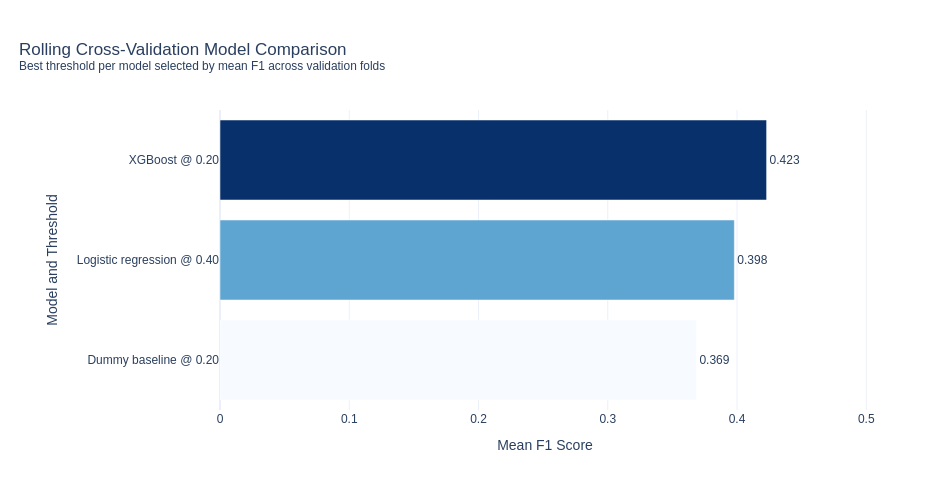

In [62]:
best_model_plot = best_threshold_by_model.copy()

best_model_plot["model_threshold"] = (
    best_model_plot["model"] +
    " @ " +
    best_model_plot["threshold"].map(lambda x: f"{x:.2f}")
)

best_model_plot = best_model_plot.sort_values("mean_f1")

fig = px.bar(
    best_model_plot,
    x="mean_f1",
    y="model_threshold",
    orientation="h",
    text="mean_f1",
    color="mean_f1",
    color_continuous_scale="Blues",
    title="Rolling Cross-Validation Model Comparison",
    labels={
        "mean_f1": "Mean F1 Score",
        "model_threshold": "Model and Selected Threshold"
    },
    hover_data={
        "mean_roc_auc": ":.3f",
        "mean_avg_precision": ":.3f",
        "mean_precision": ":.3f",
        "mean_recall": ":.3f",
        "mean_flagged_share": ":.1%",
        "threshold": ":.2f"
    }
)

fig.update_traces(
    texttemplate="%{text:.3f}",
    textposition="outside",
    cliponaxis=False
)

fig.update_layout(
    template="plotly_white",
    height=480,
    width=950,
    title=dict(
        text="Rolling Cross-Validation Model Comparison<br><sup>Best threshold per model selected by mean F1 across validation folds</sup>",
        x=0.02,
        xanchor="left"
    ),
    xaxis=dict(
        title="Mean F1 Score",
        range=[0, best_model_plot["mean_f1"].max() + 0.08]
    ),
    yaxis=dict(title="Model and Threshold"),
    coloraxis_showscale=False,
    margin=dict(t=110, r=80, b=70, l=220)
)

fig.show()

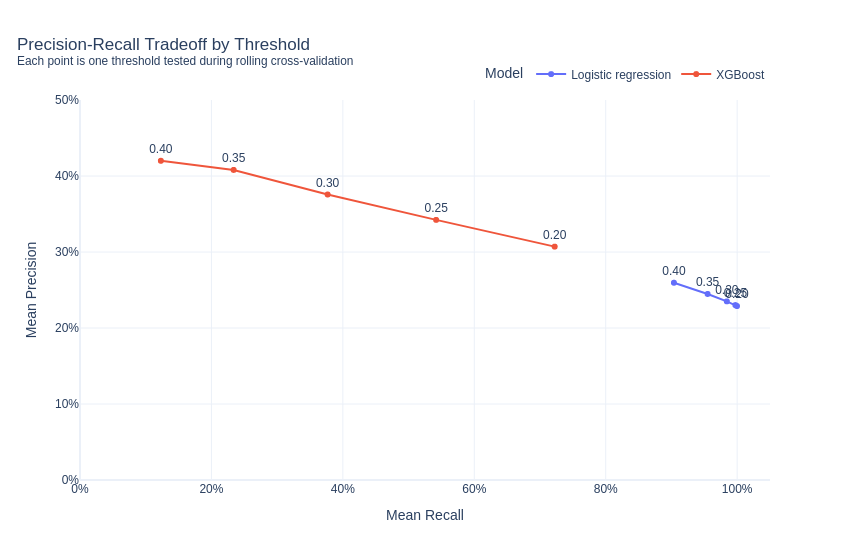

In [63]:
threshold_tradeoff = cv_threshold_summary[
    cv_threshold_summary["model"].isin(["Logistic regression", "XGBoost"])
].copy()

threshold_tradeoff["threshold_label"] = threshold_tradeoff["threshold"].map(lambda x: f"{x:.2f}")

fig = px.line(
    threshold_tradeoff,
    x="mean_recall",
    y="mean_precision",
    color="model",
    text="threshold_label",
    markers=True,
    title="Precision-Recall Tradeoff by Threshold",
    labels={
        "mean_recall": "Mean Recall",
        "mean_precision": "Mean Precision",
        "model": "Model"
    },
    hover_data={
        "threshold": ":.2f",
        "mean_f1": ":.3f",
        "mean_flagged_share": ":.1%",
        "mean_roc_auc": ":.3f",
        "mean_avg_precision": ":.3f"
    }
)

fig.update_traces(
    textposition="top center"
)

fig.update_layout(
    template="plotly_white",
    height=560,
    width=850,
    title=dict(
        text="Precision-Recall Tradeoff by Threshold<br><sup>Each point is one threshold tested during rolling cross-validation</sup>",
        x=0.02,
        xanchor="left"
    ),
    xaxis=dict(
        title="Mean Recall",
        tickformat=".0%",
        range=[0, 1.05]
    ),
    yaxis=dict(
        title="Mean Precision",
        tickformat=".0%",
        range=[0, max(0.5, threshold_tradeoff["mean_precision"].max() + 0.08)]
    ),
    legend=dict(
        title="Model",
        orientation="h",
        yanchor="bottom",
        y=1.03,
        xanchor="right",
        x=1
    )
)

fig.show()

### 6.4 Final Holdout Evaluation

After selecting the best model by rolling CV, the model is refit on January-September and evaluated on the future holdout period, October-December.


In [64]:
best_row = best_threshold_by_model.iloc[0]

best_model_name = best_row["model"]
best_threshold = best_row["threshold"]

print("Selected model:", best_model_name)
print("Selected threshold:", f"{best_threshold:.2f}")
print("CV F1:", f"{best_row['mean_f1']:.3f}")
print("CV precision:", f"{best_row['mean_precision']:.3f}")
print("CV recall:", f"{best_row['mean_recall']:.3f}")

Selected model: XGBoost
Selected threshold: 0.20
CV F1: 0.423
CV precision: 0.307
CV recall: 0.722


In [65]:
best_estimator = clone(models[best_model_name])

X_train_final = train_cv_df[numeric_features + categorical_features]
y_train_final = train_cv_df[target]

X_test = test_df[numeric_features + categorical_features]
y_test = test_df[target]

best_estimator.fit(X_train_final, y_train_final)

y_test_proba = best_estimator.predict_proba(X_test)[:, 1]

test_metrics = evaluate_classifier(
    y_test,
    y_test_proba,
    threshold=best_threshold
)

test_summary = pd.DataFrame([{
    "selected_model": best_model_name,
    "selected_threshold": best_threshold,
    "train_rows": len(X_train_final),
    "test_rows": len(X_test),
    **test_metrics
}])

test_summary

,selected_model,selected_threshold,train_rows,test_rows,threshold,roc_auc,average_precision,accuracy,precision,recall,f1,flagged_share
0,XGBoost,0.20,373277,126723,0.20,0.62,0.23,0.53,0.21,0.67,0.32,0.53


In [66]:
# Confusion matrix at default 0.50 threshold
y_test_pred = (y_test_proba >= best_threshold).astype(int)

cm = confusion_matrix(y_test, y_test_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual not delayed", "Actual delayed"],
    columns=["Predicted not delayed", "Predicted delayed"]
)

cm_df

,Predicted not delayed,Predicted delayed
Actual not delayed,53043,53005
Actual delayed,6779,13896


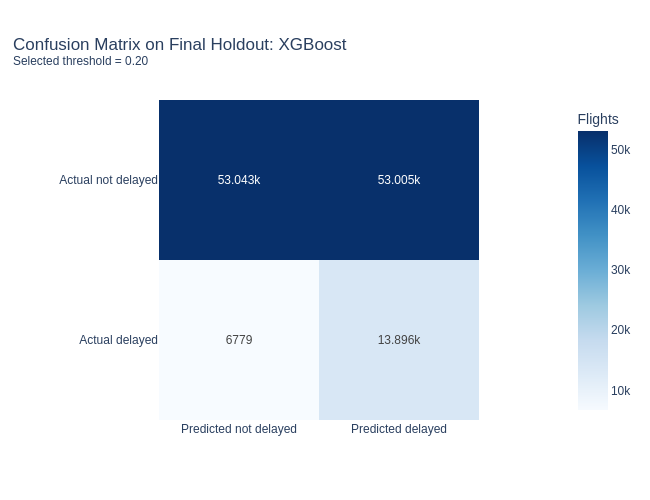

In [67]:
fig = px.imshow(
    cm_df,
    text_auto=True,
    color_continuous_scale="Blues",
    title=f"Confusion Matrix on Final Holdout: {best_model_name}"
)

fig.update_layout(
    template="plotly_white",
    height=500,
    width=650,
    title=dict(
        text=(
            f"Confusion Matrix on Final Holdout: {best_model_name}"
            f"<br><sup>Selected threshold = {best_threshold:.2f}</sup>"
        ),
        x=0.02,
        xanchor="left"
    ),
    coloraxis_colorbar=dict(title="Flights")
)

fig.show()

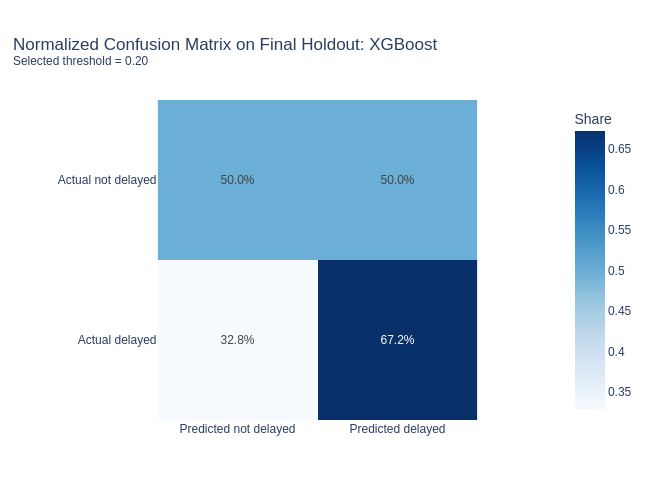

In [68]:
cm_norm = confusion_matrix(y_test, y_test_pred, normalize="true")

cm_norm_df = pd.DataFrame(
    cm_norm,
    index=["Actual not delayed", "Actual delayed"],
    columns=["Predicted not delayed", "Predicted delayed"]
)

fig = px.imshow(
    cm_norm_df,
    text_auto=".1%",
    color_continuous_scale="Blues",
    title=f"Normalized Confusion Matrix on Final Holdout: {best_model_name}"
)

fig.update_layout(
    template="plotly_white",
    height=500,
    width=650,
    title=dict(
        text=(
            f"Normalized Confusion Matrix on Final Holdout: {best_model_name}"
            f"<br><sup>Selected threshold = {best_threshold:.2f}</sup>"
        ),
        x=0.02,
        xanchor="left"
    ),
    coloraxis_colorbar=dict(title="Share")
)

fig.show()

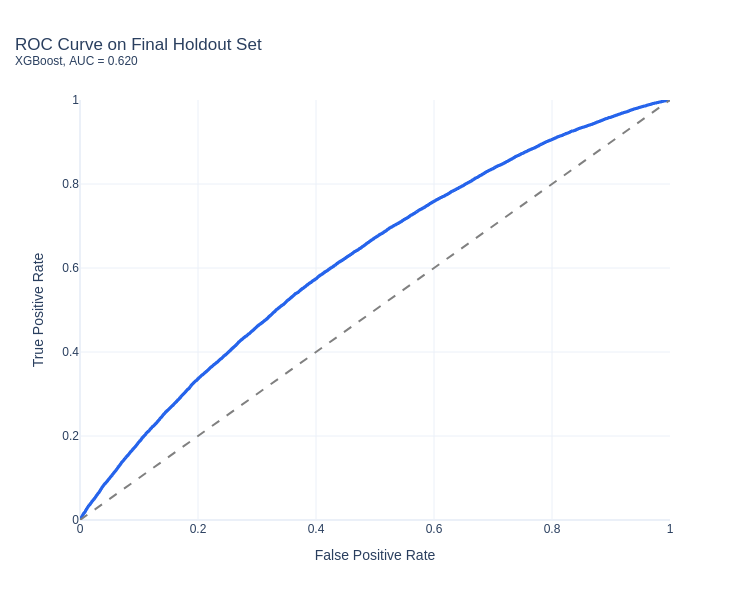

In [69]:

fpr, tpr, roc_thresholds = roc_curve(y_test, y_test_proba)
holdout_auc = auc(fpr, tpr)

roc_df = pd.DataFrame({
    "false_positive_rate": fpr,
    "true_positive_rate": tpr,
    "threshold": roc_thresholds
})

fig = px.line(
    roc_df,
    x="false_positive_rate",
    y="true_positive_rate",
    title="ROC Curve on Final Holdout Set",
    labels={
        "false_positive_rate": "False Positive Rate",
        "true_positive_rate": "True Positive Rate"
    },
    hover_data={
        "threshold": ":.3f",
        "false_positive_rate": ":.3f",
        "true_positive_rate": ":.3f"
    }
)

fig.add_shape(
    type="line",
    x0=0,
    y0=0,
    x1=1,
    y1=1,
    line=dict(color="gray", dash="dash")
)

fig.update_traces(line=dict(color="#2563EB", width=3))

fig.update_layout(
    template="plotly_white",
    height=600,
    width=750,
    title=dict(
        text=f"ROC Curve on Final Holdout Set<br><sup>{best_model_name}, AUC = {holdout_auc:.3f}</sup>",
        x=0.02,
        xanchor="left"
    ),
    xaxis=dict(range=[0, 1]),
    yaxis=dict(range=[0, 1])
)

fig.show()

### 6.5 Threshold Tuning

The default 0.50 threshold may not be ideal for delay-risk screening. If the business goal is to flag more high-risk flights, recall matters more; if the goal is to avoid too many false alarms, precision matters more. The chart below shows the precision/recall tradeoff across thresholds.


In [70]:
threshold_rows = []

threshold_grid = np.round(np.arange(0.10, 0.91, 0.05), 2)

for threshold in threshold_grid:
    y_pred = (y_test_proba >= threshold).astype(int)

    threshold_rows.append({
        "threshold": threshold,
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_test, y_pred),
        "flagged_share": y_pred.mean(),
        "selected_from_cv": np.isclose(threshold, best_threshold)
    })

threshold_df = pd.DataFrame(threshold_rows)

threshold_df.sort_values("f1", ascending=False).head(10)

,threshold,precision,recall,f1,accuracy,flagged_share,selected_from_cv
2,0.20,0.21,0.67,0.32,0.53,0.53,True
3,0.25,0.23,0.49,0.31,0.64,0.36,False
1,0.15,0.19,0.84,0.31,0.39,0.72,False
0,0.10,0.17,0.96,0.29,0.24,0.91,False
4,0.30,0.25,0.34,0.29,0.72,0.23,False
5,0.35,0.26,0.20,0.23,0.78,0.12,False
6,0.40,0.28,0.10,0.15,0.81,0.06,False
7,0.45,0.30,0.04,0.07,0.83,0.02,False
8,0.50,0.33,0.01,0.02,0.84,0.00,False
9,0.55,0.35,0.00,0.00,0.84,0.00,False


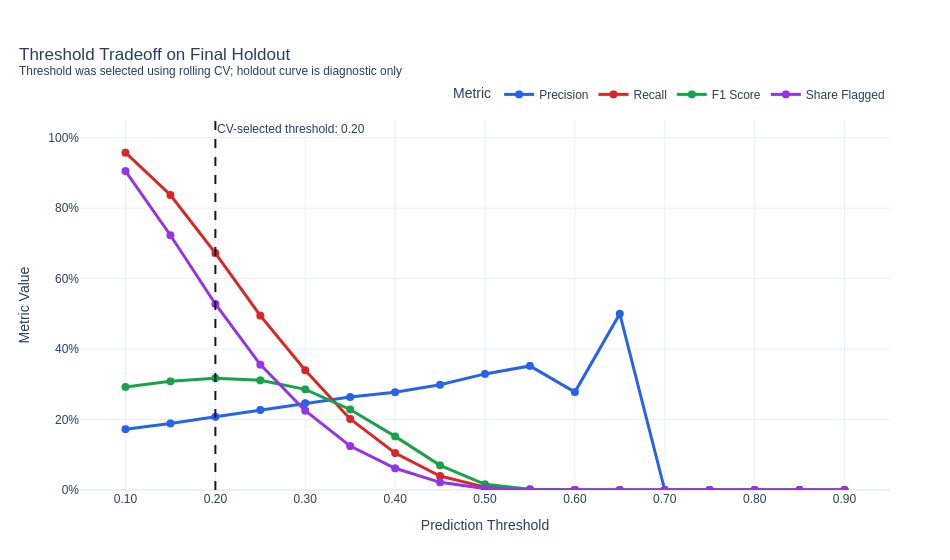

In [71]:
threshold_long = threshold_df.melt(
    id_vars=["threshold", "selected_from_cv"],
    value_vars=["precision", "recall", "f1", "flagged_share"],
    var_name="metric",
    value_name="value"
)

metric_name_map = {
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1 Score",
    "flagged_share": "Share Flagged"
}

threshold_long["metric"] = threshold_long["metric"].map(metric_name_map)

fig = px.line(
    threshold_long,
    x="threshold",
    y="value",
    color="metric",
    markers=True,
    title="Threshold Tradeoff on Final Holdout",
    labels={
        "threshold": "Prediction Threshold",
        "value": "Metric Value",
        "metric": "Metric"
    },
    hover_data={
        "threshold": ":.2f",
        "value": ":.1%",
        "selected_from_cv": True
    },
    color_discrete_map={
        "Precision": "#2563EB",
        "Recall": "#DC2626",
        "F1 Score": "#16A34A",
        "Share Flagged": "#9333EA"
    }
)

fig.add_vline(
    x=best_threshold,
    line_dash="dash",
    line_color="#111827",
    annotation_text=f"CV-selected threshold: {best_threshold:.2f}",
    annotation_position="top right"
)

fig.update_traces(line=dict(width=3), marker=dict(size=8))

fig.update_layout(
    template="plotly_white",
    height=560,
    width=950,
    title=dict(
        text=(
            "Threshold Tradeoff on Final Holdout"
            "<br><sup>Threshold was selected using rolling CV; holdout curve is diagnostic only</sup>"
        ),
        x=0.02,
        xanchor="left"
    ),
    xaxis=dict(
        title="Prediction Threshold",
        tickformat=".2f"
    ),
    yaxis=dict(
        title="Metric Value",
        tickformat=".0%",
        range=[0, 1.05]
    ),
    legend=dict(
        title="Metric",
        orientation="h",
        yanchor="bottom",
        y=1.03,
        xanchor="right",
        x=1
    ),
    hovermode="x unified",
    margin=dict(t=120, r=60, b=70, l=80)
)

fig.show()

### 6.6 Model Interpretation

The preferred interpretation method depends on which model wins cross-validation. For a tree-based model, permutation importance is model-agnostic and easy to explain. It measures how much model performance drops when a feature is randomly shuffled.


In [72]:
from sklearn.inspection import permutation_importance

IMPORTANCE_SAMPLE_SIZE = 50_000

importance_df = test_df.sample(
    n=min(IMPORTANCE_SAMPLE_SIZE, len(test_df)),
    random_state=42
)

X_importance = importance_df[numeric_features + categorical_features]
y_importance = importance_df[target]

perm = permutation_importance(
    best_estimator,
    X_importance,
    y_importance,
    scoring="roc_auc",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

feature_importance = (
    pd.DataFrame({
        "feature": numeric_features + categorical_features,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

feature_importance

,feature,importance_mean,importance_std
0,sched_dep_hour,0.04,0.00
1,Reporting_Airline,0.02,0.00
2,sched_arr_hour,0.02,0.00
3,DayOfWeek,0.01,0.00
4,Dest,0.01,0.00
5,Origin,0.00,0.00
6,origin_annual_volume,0.00,0.00
7,dest_annual_volume,0.00,0.00
8,Distance,0.00,0.00
9,CRSElapsedTime,0.00,0.00


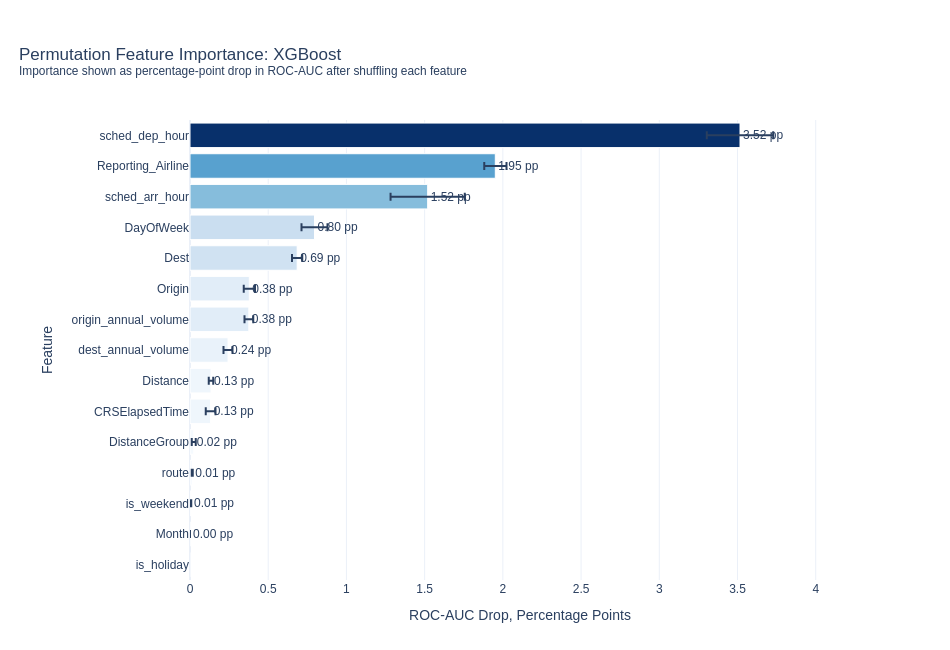

In [73]:
feature_importance_plot = feature_importance.copy()

# Convert raw ROC-AUC drop to percentage points
feature_importance_plot["importance_pp"] = feature_importance_plot["importance_mean"] * 100
feature_importance_plot["importance_std_pp"] = feature_importance_plot["importance_std"] * 100

top_importance = (
    feature_importance_plot
    .head(15)
    .sort_values("importance_pp")
    .copy()
)

top_importance["importance_label"] = top_importance["importance_pp"].map(lambda x: f"{x:.2f} pp")

fig = px.bar(
    top_importance,
    x="importance_pp",
    y="feature",
    orientation="h",
    error_x="importance_std_pp",
    text="importance_label",
    title=f"Permutation Feature Importance: {best_model_name}",
    labels={
        "importance_pp": "ROC-AUC Drop, Percentage Points",
        "feature": "Feature"
    },
    color="importance_pp",
    color_continuous_scale="Blues",
    hover_data={
        "importance_pp": ":.2f",
        "importance_std_pp": ":.2f",
        "importance_mean": ":.4f",
        "importance_std": ":.4f",
        "importance_label": False
    }
)

fig.update_traces(
    textposition="outside",
    cliponaxis=False,
    marker_line_color="white",
    marker_line_width=1
)

fig.update_layout(
    template="plotly_white",
    height=650,
    width=950,
    title=dict(
        text=(
            f"Permutation Feature Importance: {best_model_name}"
            "<br><sup>Importance shown as percentage-point drop in ROC-AUC after shuffling each feature</sup>"
        ),
        x=0.02,
        xanchor="left"
    ),
    xaxis=dict(
        title="ROC-AUC Drop, Percentage Points",
        range=[0, max(0.1, top_importance["importance_pp"].max() * 1.20)]
    ),
    yaxis=dict(title="Feature"),
    coloraxis_showscale=False,
    margin=dict(t=120, r=100, b=70, l=190)
)

fig.show()

### Modeling Summary

Using rolling monthly cross-validation, XGBoost performed best among the dummy baseline, logistic regression, and nonlinear tree-based model candidates. It achieved the strongest ROC-AUC and average precision, showing better delay-risk ranking than the other models.

The default 0.50 threshold was too conservative for XGBoost, resulting in low recall. After threshold tuning, a 0.20 threshold produced the best average F1 score across validation folds. Logistic regression achieved higher recall but flagged a much larger share of flights, while XGBoost offered a better balance between precision, recall, and selectivity.

Permutation importance shows that scheduled departure hour, reporting airline, scheduled arrival hour, day of week, and destination airport are the most influential predictors. These results are consistent with the EDA findings that delay risk varies by time of day, airline, airport, and network patterns.

The final model is most useful as a delay-risk ranking or screening tool rather than a perfect classifier. Future improvements could include weather data, aircraft rotation data, crew information, and real-time airport congestion.